# Imports & Loading the data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde, pointbiserialr, spearmanr
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns



In [2]:
# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv("dataset_wave2_only.csv")

In [3]:
df.columns

Index(['X4EVERDROP', 'X2MTHEFF', 'X2SCIEFF', 'X2TXMTSCOR', 'X2BEHAVEIN',
       'X2PAREDEXPCT', 'X2STUEDEXPCT', 'S2GRD1011', 'S2GRD1112', 'X2REQLEVEL',
       'S2SUREDIPL', 'S2ALG1GRADE', 'S2EDUEXP', 'S2PAYOFF', 'S2DOOKAY',
       'X2POVERTY', 'S2ENROLLHS12'],
      dtype='object')

# EDA - STEP 1: Target Variable Analysis + Sample Comparison.

  TARGET VARIABLE SUMMARY  (X4EVERDROP) — WAVE 2
  Total students        : 15,236
  Dropout     (1)       : 1,939  (12.73%)
  No dropout  (0)       : 13,297  (87.27%)
  Imbalance ratio (0:1) : 6.9 : 1

  WAVE 1 → WAVE 2 SAMPLE COMPARISON
  Wave 1 students       : 15,900
  Wave 2 students       : 15,236
  Students lost         : 664  (4.2% of Wave 1)
  Dropout rate — W1     : 15.4%
  Dropout rate — W2     : 12.73%
  Rate drop             : 2.64pp
  Imbalance ratio — W1  : 5.5 : 1
  Imbalance ratio — W2  : 6.9 : 1


/tmp/ipykernel_4581/658430455.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


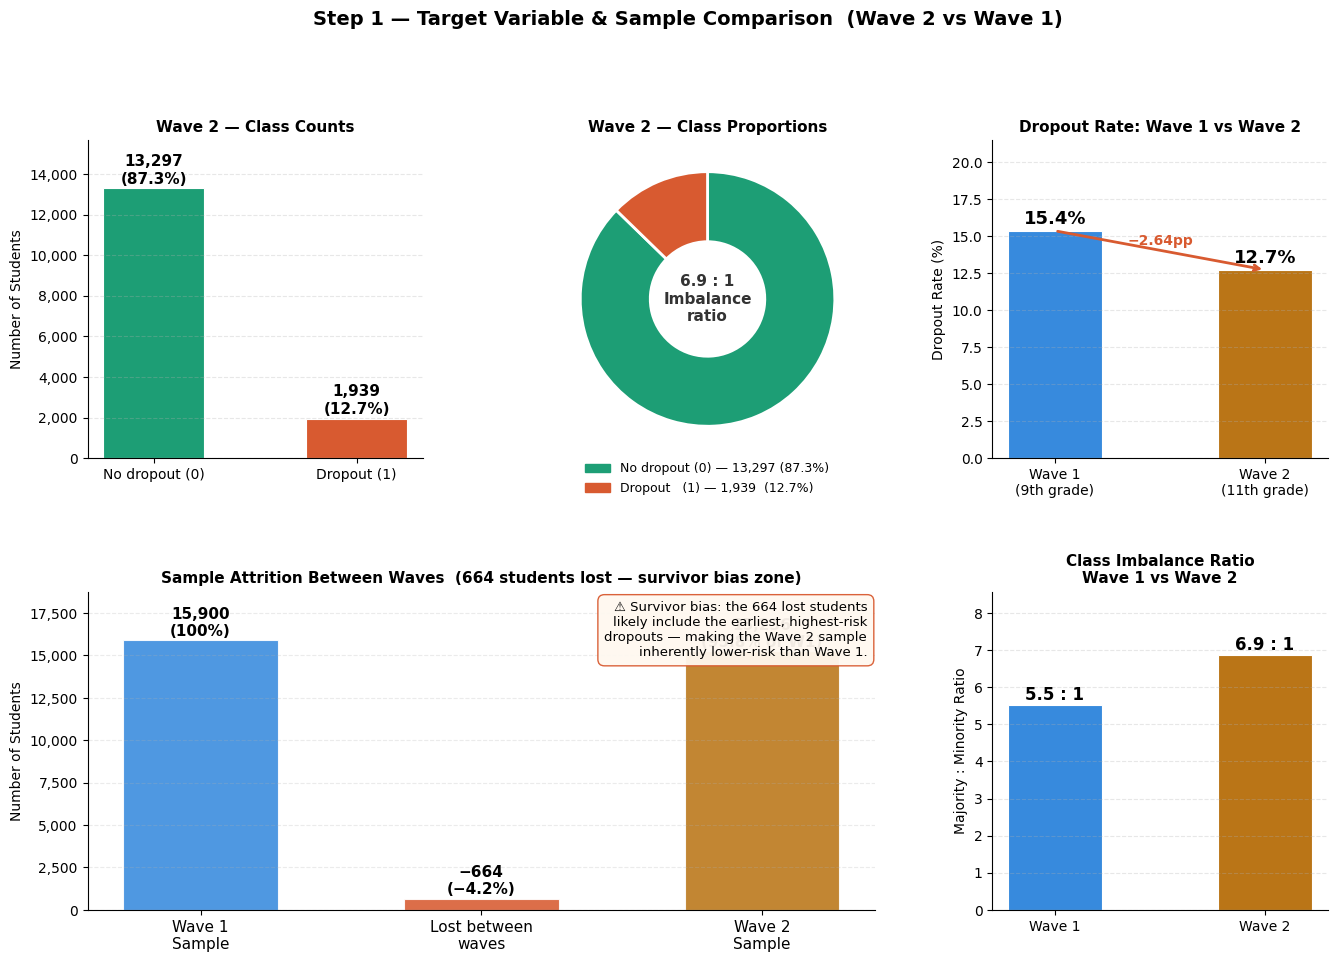

Saved → w2_step1_target_comparison.png


In [4]:
# ── Palette ──────────────────────────────────────────────────
C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

# ── Wave 2 counts ─────────────────────────────────────────────
total_w2   = len(df)
drop_w2    = int(df["X4EVERDROP"].sum())
nodrop_w2  = total_w2 - drop_w2
pct_drop_w2  = drop_w2  / total_w2 * 100
pct_nodrop_w2= nodrop_w2 / total_w2 * 100
ratio_w2   = nodrop_w2 / drop_w2

# ── Wave 1 reference numbers (from EDA notebook) ──────────────
total_w1    = 15_900
drop_w1     = 2_443
nodrop_w1   = total_w1 - drop_w1
pct_drop_w1 = drop_w1  / total_w1 * 100
ratio_w1    = nodrop_w1 / drop_w1

# ── Students lost between waves ───────────────────────────────
n_lost      = total_w1 - total_w2       # 664
pct_lost    = n_lost / total_w1 * 100

print("=" * 55)
print("  TARGET VARIABLE SUMMARY  (X4EVERDROP) — WAVE 2")
print("=" * 55)
print(f"  Total students        : {total_w2:,}")
print(f"  Dropout     (1)       : {drop_w2:,}  ({pct_drop_w2:.2f}%)")
print(f"  No dropout  (0)       : {nodrop_w2:,}  ({pct_nodrop_w2:.2f}%)")
print(f"  Imbalance ratio (0:1) : {ratio_w2:.1f} : 1")
print("=" * 55)
print()
print("=" * 55)
print("  WAVE 1 → WAVE 2 SAMPLE COMPARISON")
print("=" * 55)
print(f"  Wave 1 students       : {total_w1:,}")
print(f"  Wave 2 students       : {total_w2:,}")
print(f"  Students lost         : {n_lost:,}  ({pct_lost:.1f}% of Wave 1)")
print(f"  Dropout rate — W1     : {pct_drop_w1:.1f}%")
print(f"  Dropout rate — W2     : {pct_drop_w2:.2f}%")
print(f"  Rate drop             : {pct_drop_w1 - pct_drop_w2:.2f}pp")
print(f"  Imbalance ratio — W1  : {ratio_w1:.1f} : 1")
print(f"  Imbalance ratio — W2  : {ratio_w2:.1f} : 1")
print("=" * 55)


# ─────────────────────────────────────────────────────────────
# FIGURE 1-1  Class balance: Wave 2 (bar + donut)
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Step 1 — Target Variable & Sample Comparison  (Wave 2 vs Wave 1)",
             fontsize=14, fontweight="bold", y=1.01)

gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── Panel A: Wave 2 bar chart ─────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 0])
bars = ax_bar.bar(
    ["No dropout (0)", "Dropout (1)"],
    [nodrop_w2, drop_w2],
    color=[C_TEAL, C_CORAL],
    edgecolor="white", linewidth=0.8, width=0.5
)
for bar, count, pct in zip(bars, [nodrop_w2, drop_w2],
                            [pct_nodrop_w2, pct_drop_w2]):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100,
                f"{count:,}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax_bar.set_title("Wave 2 — Class Counts", fontsize=11, fontweight="bold")
ax_bar.set_ylabel("Number of Students")
ax_bar.set_ylim(0, nodrop_w2 * 1.18)
ax_bar.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax_bar.spines[["top","right"]].set_visible(False)
ax_bar.grid(axis="y", alpha=0.3, linestyle="--")

# ── Panel B: Wave 2 donut ─────────────────────────────────────
ax_pie = fig.add_subplot(gs[0, 1])
wedges, _ = ax_pie.pie(
    [nodrop_w2, drop_w2],
    colors=[C_TEAL, C_CORAL],
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    counterclock=False
)
ax_pie.text(0, 0, f"{ratio_w2:.1f} : 1\nImbalance\nratio",
            ha="center", va="center",
            fontsize=11, fontweight="bold", color="#333333")
ax_pie.set_title("Wave 2 — Class Proportions", fontsize=11, fontweight="bold")
ax_pie.legend(
    handles=[
        mpatches.Patch(color=C_TEAL,  label=f"No dropout (0) — {nodrop_w2:,} ({pct_nodrop_w2:.1f}%)"),
        mpatches.Patch(color=C_CORAL, label=f"Dropout   (1) — {drop_w2:,}  ({pct_drop_w2:.1f}%)")
    ],
    loc="lower center", bbox_to_anchor=(0.5, -0.15),
    fontsize=9, frameon=False
)

# ── Panel C: Wave 1 vs Wave 2 side-by-side dropout rates ──────
ax_comp = fig.add_subplot(gs[0, 2])
waves      = ["Wave 1\n(9th grade)", "Wave 2\n(11th grade)"]
dr_vals    = [pct_drop_w1, pct_drop_w2]
bar_colors = [C_BLUE, C_AMBER]

comp_bars = ax_comp.bar(waves, dr_vals, color=bar_colors,
                         edgecolor="white", linewidth=0.8, width=0.45)
for bar, v in zip(comp_bars, dr_vals):
    ax_comp.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{v:.1f}%", ha="center", va="bottom",
                 fontsize=13, fontweight="bold")

# Annotate the drop
ax_comp.annotate("",
    xy=(1, pct_drop_w2), xytext=(0, pct_drop_w1),
    arrowprops=dict(arrowstyle="->", color=C_CORAL, lw=2))
ax_comp.text(0.5, (pct_drop_w1 + pct_drop_w2)/2 + 0.4,
             f"−{pct_drop_w1 - pct_drop_w2:.2f}pp",
             ha="center", fontsize=10, fontweight="bold", color=C_CORAL)

ax_comp.set_ylabel("Dropout Rate (%)")
ax_comp.set_title("Dropout Rate: Wave 1 vs Wave 2", fontsize=11, fontweight="bold")
ax_comp.set_ylim(0, pct_drop_w1 * 1.4)
ax_comp.spines[["top","right"]].set_visible(False)
ax_comp.grid(axis="y", alpha=0.3, linestyle="--")


# ── Panel D: Sample funnel (students lost between waves) ───────
ax_funnel = fig.add_subplot(gs[1, :2])

categories  = ["Wave 1\nSample", "Lost between\nwaves", "Wave 2\nSample"]
counts      = [total_w1, n_lost, total_w2]
colors_f    = [C_BLUE, C_CORAL, C_AMBER]
pct_labels  = [
    f"{total_w1:,}\n(100%)",
    f"−{n_lost:,}\n(−{pct_lost:.1f}%)",
    f"{total_w2:,}\n({total_w2/total_w1*100:.1f}% of W1)"
]

xpos = [0, 1, 2]
bars_f = ax_funnel.bar(xpos, [total_w1, n_lost, total_w2],
                        color=colors_f, edgecolor="white",
                        linewidth=0.8, width=0.55, alpha=0.88)
for bar, lbl in zip(bars_f, pct_labels):
    ax_funnel.text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 80,
                   lbl, ha="center", va="bottom",
                   fontsize=11, fontweight="bold")

ax_funnel.set_xticks(xpos)
ax_funnel.set_xticklabels(categories, fontsize=11)
ax_funnel.set_ylabel("Number of Students")
ax_funnel.set_title(
    f"Sample Attrition Between Waves  "
    f"({n_lost:,} students lost — survivor bias zone)",
    fontsize=11, fontweight="bold")
ax_funnel.set_ylim(0, total_w1 * 1.18)
ax_funnel.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax_funnel.spines[["top","right"]].set_visible(False)
ax_funnel.grid(axis="y", alpha=0.25, linestyle="--")

# Survivor bias annotation box
ax_funnel.text(0.99, 0.97,
    "⚠ Survivor bias: the 664 lost students\n"
    "likely include the earliest, highest-risk\n"
    "dropouts — making the Wave 2 sample\n"
    "inherently lower-risk than Wave 1.",
    transform=ax_funnel.transAxes,
    ha="right", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", fc="#FFF8F0",
              ec=C_CORAL, alpha=0.95))


# ── Panel E: Imbalance ratio comparison ───────────────────────
ax_ratio = fig.add_subplot(gs[1, 2])
ratio_vals  = [ratio_w1, ratio_w2]
ratio_bars  = ax_ratio.bar(["Wave 1", "Wave 2"], ratio_vals,
                             color=[C_BLUE, C_AMBER],
                             edgecolor="white", linewidth=0.8, width=0.45)
for bar, v in zip(ratio_bars, ratio_vals):
    ax_ratio.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.05,
                  f"{v:.1f} : 1",
                  ha="center", va="bottom",
                  fontsize=12, fontweight="bold")
ax_ratio.set_ylabel("Majority : Minority Ratio")
ax_ratio.set_title("Class Imbalance Ratio\nWave 1 vs Wave 2",
                    fontsize=11, fontweight="bold")
ax_ratio.set_ylim(0, max(ratio_vals) * 1.25)
ax_ratio.spines[["top","right"]].set_visible(False)
ax_ratio.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("w2_step1_target_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step1_target_comparison.png")

## Key Takeaways — Step 1: Target Variable Analysis + Sample Comparison

**Wave 2 class balance:**
- 15,236 students total — 1,939 (12.73%) dropout, 13,297 (87.27%) no dropout
- Imbalance ratio is now **6.9:1**, more severe than Wave 1's 5.5:1
- The minority class is smaller in absolute number *and* relative share

**Sample attrition:**
- 664 students present in Wave 1 are absent from Wave 2 — a 4.2% reduction
- The dropout rate *fell* from 15.4% → 12.73% (−2.67pp) between waves
- This decline is almost certainly **not** improvement — it is survivor bias

**Survivor bias — the most important framing issue for Wave 2:**
- The 664 missing students almost certainly skew toward the highest-risk end
  of the Wave 1 distribution: low grades, low expectations, poverty flags
- Their absence from Wave 2 mechanically deflates the observed dropout rate
  and compresses the risk signal in every feature
- Any Wave 2 model is therefore trained on a **pre-screened, lower-risk sample**
  — which means its predictions will underestimate risk for the most vulnerable
  students, precisely those it most needs to identify
- This bias cannot be corrected without Wave 1 data on the lost students
  (addressed in Step 9)

**Modeling implications:**
- Class weighting, SMOTE, and threshold tuning remain necessary — the 6.9:1
  ratio is *worse* than Wave 1's despite the lower headline dropout rate
- Recall on the dropout class is still the priority metric
- Any performance comparison between Wave 1 and Wave 2 models must account
  for the fact that the Wave 2 target is easier to predict simply because
  the hardest cases have already been removed from the sample

## Hypotheses

1. **The Wave 2 model will show artificially inflated performance vs Wave 1.**
   Because the highest-risk students have self-selected out of the Wave 2 sample,
   any model trained on Wave 2 data will face an easier classification problem.
   ROC-AUC and F1 may appear better than Wave 1 even if the underlying feature
   signals are no stronger — a direct result of survivor bias narrowing the
   risk distribution.

2. **The 664 lost students will prove to have been the most at-risk in Wave 1.**
   When we examine them in Step 9 using Wave 1 features, we expect to find
   significantly higher poverty rates, lower math scores, lower expectations,
   and higher `X1PAR_SURVEY_MISSING` flags than the students who remained.

3. **The imbalance will require more aggressive handling in Wave 2 than Wave 1.**
   At 6.9:1, the minority class is proportionally smaller — a model that simply
   learns the majority class will be even harder to beat here. We anticipate
   that threshold tuning alone (without resampling) will be insufficient to
   achieve acceptable recall on the dropout class.

# EDA - STEP 2: Data Quality Check.

  SECTION A — COMPLETENESS
  Total cells   : 243,776
  Missing cells : 0
  All features complete: True

  (contrast: Wave 1 had 7 features with missing values,
   including 3,017-row MNAR parent block + structural NaNs)

  SECTION B — NEAR-CONSTANT FEATURES

  Feature                 Top value   Count       %  Flag
  ----------------------------------------------------------
  S2ENROLLHS12                  1.0  15,059   98.8%  ⚠ NEAR-CONSTANT
  S2GRD1112                     3.0  14,701   96.5%  ⚠ NEAR-CONSTANT
  S2GRD1011                     2.0  14,655   96.2%  ⚠ NEAR-CONSTANT
  S2SUREDIPL                    1.0  13,896   91.2%  ⚠ NEAR-CONSTANT
  X2POVERTY                     0.0  13,081   85.9%  ⚠ NEAR-CONSTANT
  X2REQLEVEL                    4.0   9,762   64.1%  
  S2PAYOFF                      3.0   7,430   48.8%  
  S2ALG1GRADE                   1.0   7,170   47.1%  
  S2DOOKAY                      3.0   6,636   43.6%  
  X2SCIEFF                     0.27   5,191   34.1%  
  X2PAR

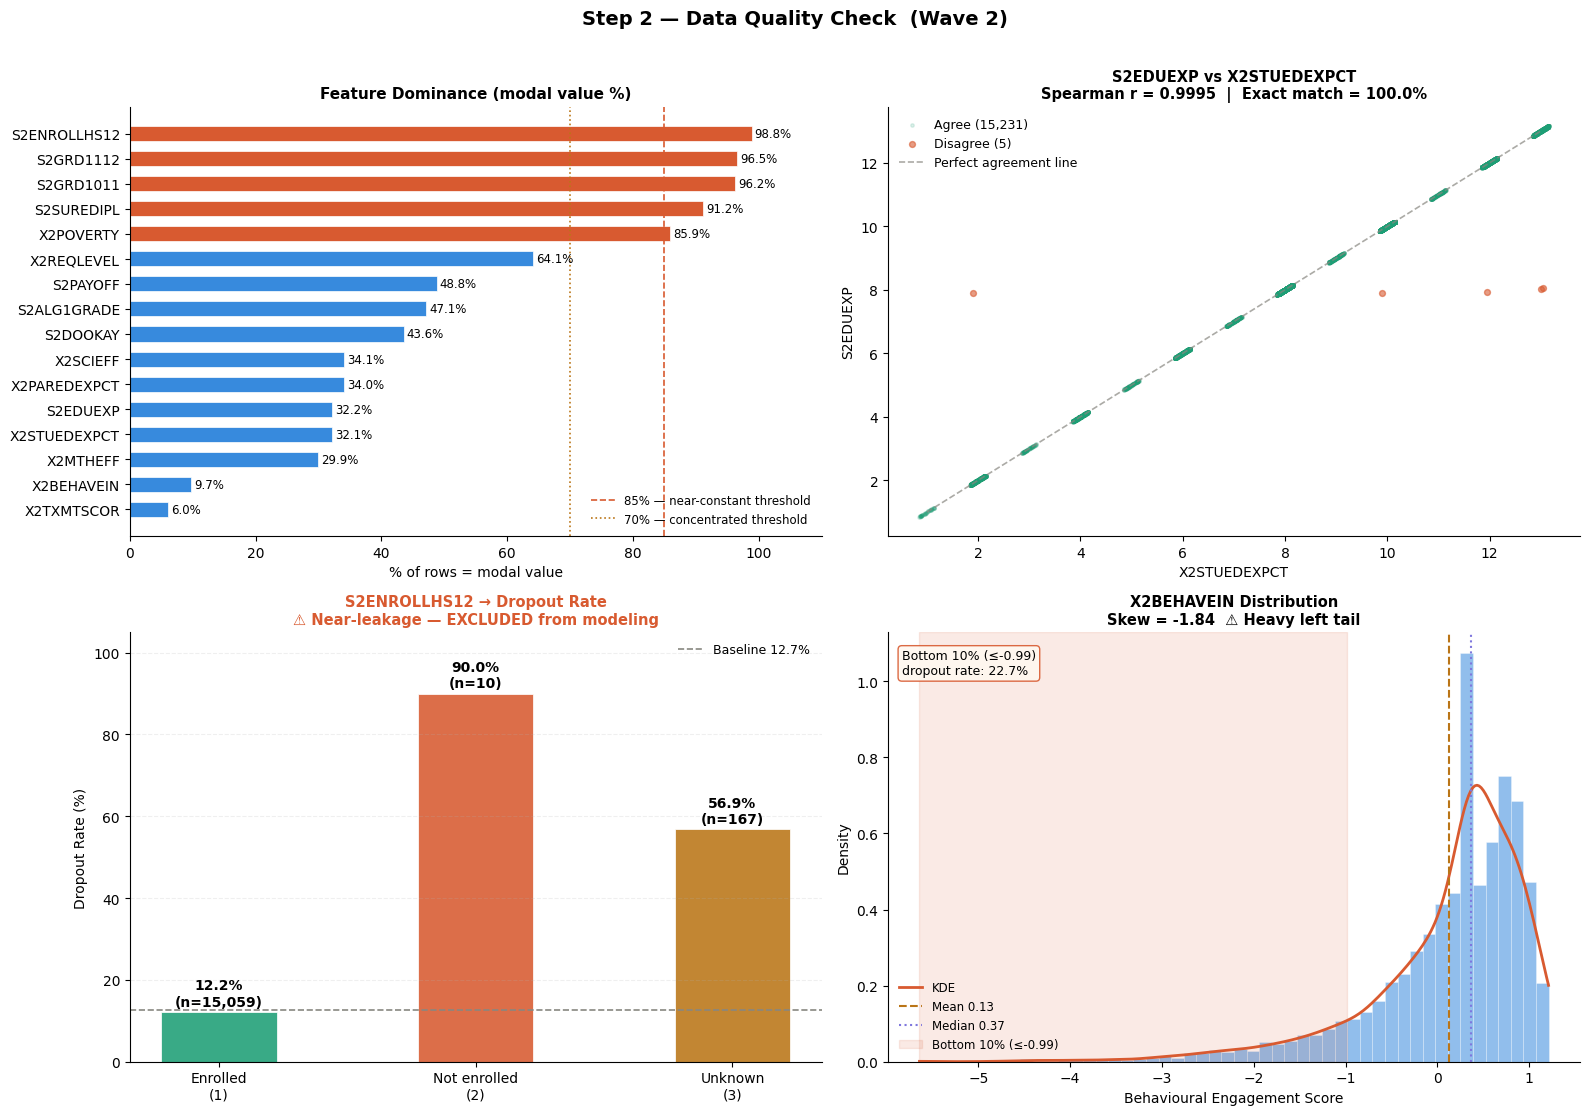

Saved → w2_step2_data_quality.png

Dataset after exclusions: 15,236 rows × 14 features
Modelling features: ['X2MTHEFF', 'X2SCIEFF', 'X2TXMTSCOR', 'X2BEHAVEIN', 'X2PAREDEXPCT', 'X2STUEDEXPCT', 'S2GRD1011', 'S2GRD1112', 'X2REQLEVEL', 'S2SUREDIPL', 'S2ALG1GRADE', 'S2PAYOFF', 'S2DOOKAY', 'X2POVERTY']


In [5]:
# ── Palette ───────────────────────────────────────────────────
C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

FEATURES = [c for c in df.columns if c != "X4EVERDROP"]

# ─────────────────────────────────────────────────────────────
# SECTION A — Completeness confirmation
# ─────────────────────────────────────────────────────────────
miss = df[FEATURES].isnull().sum()
print("=" * 55)
print("  SECTION A — COMPLETENESS")
print("=" * 55)
print(f"  Total cells   : {len(df) * len(FEATURES):,}")
print(f"  Missing cells : {miss.sum()}")
print(f"  All features complete: {miss.sum() == 0}")
print(f"\n  (contrast: Wave 1 had 7 features with missing values,")
print(f"   including 3,017-row MNAR parent block + structural NaNs)")


# ─────────────────────────────────────────────────────────────
# SECTION B — Near-constant features (dominance check)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  SECTION B — NEAR-CONSTANT FEATURES")
print("=" * 55)
dominance = []
for col in FEATURES:
    top_val   = df[col].value_counts().index[0]
    top_count = df[col].value_counts().iloc[0]
    top_pct   = top_count / len(df) * 100
    dominance.append((col, top_val, top_count, top_pct))

dominance.sort(key=lambda x: -x[3])
print(f"\n  {'Feature':<22} {'Top value':>10} {'Count':>7} {'%':>7}  Flag")
print("  " + "-"*58)
for col, val, cnt, pct in dominance:
    flag = "⚠ NEAR-CONSTANT" if pct >= 85 else \
           "△ Concentrated"  if pct >= 70 else ""
    print(f"  {col:<22} {str(val):>10} {cnt:>7,} {pct:>6.1f}%  {flag}")


# ─────────────────────────────────────────────────────────────
# SECTION C — S2EDUEXP vs X2STUEDEXPCT redundancy check
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  SECTION C — NEAR-DUPLICATE: S2EDUEXP vs X2STUEDEXPCT")
print("=" * 55)

exact_match = (df["S2EDUEXP"] == df["X2STUEDEXPCT"]).sum()
exact_pct   = exact_match / len(df) * 100
r_sp, p_sp  = spearmanr(df["S2EDUEXP"], df["X2STUEDEXPCT"])

# Dropout rate correlation difference
r_eduexp,   _ = spearmanr(df["S2EDUEXP"],      df["X4EVERDROP"])
r_stuedexpct,_ = spearmanr(df["X2STUEDEXPCT"], df["X4EVERDROP"])

print(f"\n  Row-level exact match     : {exact_match:,} / {len(df):,}  ({exact_pct:.2f}%)")
print(f"  Spearman r (vs each other): {r_sp:.4f}  (p < 0.001)")
print(f"  Value range S2EDUEXP      : {df['S2EDUEXP'].min():.0f} – {df['S2EDUEXP'].max():.0f}")
print(f"  Value range X2STUEDEXPCT  : {df['X2STUEDEXPCT'].min():.0f} – {df['X2STUEDEXPCT'].max():.0f}")
print(f"\n  Spearman r with X4EVERDROP:")
print(f"    S2EDUEXP      : {r_eduexp:.4f}")
print(f"    X2STUEDEXPCT  : {r_stuedexpct:.4f}")
print(f"\n  Difference in rows where they disagree:")
disagree = df[df["S2EDUEXP"] != df["X2STUEDEXPCT"]]
print(f"    N rows disagree : {len(disagree):,}  ({len(disagree)/len(df)*100:.2f}%)")
if len(disagree) > 0:
    print(f"    Mean |diff|     : {(disagree['S2EDUEXP'] - disagree['X2STUEDEXPCT']).abs().mean():.3f}")
    dr_agree    = df.loc[df["S2EDUEXP"]==df["X2STUEDEXPCT"], "X4EVERDROP"].mean()*100
    dr_disagree = df.loc[df["S2EDUEXP"]!=df["X2STUEDEXPCT"], "X4EVERDROP"].mean()*100
    print(f"    Dropout rate (agree rows)   : {dr_agree:.1f}%")
    print(f"    Dropout rate (disagree rows): {dr_disagree:.1f}%")

print(f"\n  → DECISION: Drop S2EDUEXP — X2STUEDEXPCT is the canonical")
print(f"    HSLS variable name; S2EDUEXP adds no independent information.")


# ─────────────────────────────────────────────────────────────
# SECTION D — S2ENROLLHS12 leakage risk assessment
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  SECTION D — S2ENROLLHS12 LEAKAGE RISK")
print("=" * 55)
enroll_vc = df["S2ENROLLHS12"].value_counts().sort_index()
labels = {1.0: "Enrolled (1)", 2.0: "Not enrolled (2)", 3.0: "Unknown (3)"}
print(f"\n  {'Value':<18} {'Count':>7} {'%':>7}  {'Dropout rate':>13}")
print("  " + "-"*50)
for val, cnt in enroll_vc.items():
    pct  = cnt / len(df) * 100
    dr   = df.loc[df["S2ENROLLHS12"]==val, "X4EVERDROP"].mean() * 100
    flag = "  ⚠ NEAR-LEAKAGE" if dr > 50 else ""
    print(f"  {labels.get(val, str(val)):<18} {cnt:>7,} {pct:>6.1f}%  {dr:>12.1f}%{flag}")

r_enr, _ = spearmanr(df["S2ENROLLHS12"], df["X4EVERDROP"])
print(f"\n  Spearman r with target : {r_enr:.4f}")
print(f"\n  → DECISION: EXCLUDE from modeling.")
print(f"    Enrollment status at 12th grade is measured at/after the")
print(f"    dropout event — using it would be target leakage.")
print(f"    Retain only for Step 9 survivor analysis.")


# ─────────────────────────────────────────────────────────────
# SECTION E — Skew assessment (continuous features)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  SECTION E — SKEW & DISTRIBUTION FLAGS")
print("=" * 55)
continuous = ["X2MTHEFF", "X2SCIEFF", "X2TXMTSCOR", "X2BEHAVEIN"]
print(f"\n  {'Feature':<16} {'Min':>7} {'Max':>7} {'Mean':>7} "
      f"{'SD':>6} {'Skew':>7}  Flag")
print("  " + "-"*65)
for col in continuous:
    d = df[col]
    flag = "⚠ HEAVY LEFT SKEW" if d.skew() < -1 else \
           "△ Mild skew"        if abs(d.skew()) > 0.4 else ""
    print(f"  {col:<16} {d.min():>7.2f} {d.max():>7.2f} "
          f"{d.mean():>7.2f} {d.std():>6.2f} {d.skew():>7.2f}  {flag}")

print(f"\n  X2BEHAVEIN note: skew = −1.84 is the most extreme in the")
print(f"  dataset. Most students report positive behaviour engagement;")
print(f"  a long left tail of disengaged students. This tail is likely")
print(f"  disproportionately predictive — inspect carefully in Step 4.")


# ─────────────────────────────────────────────────────────────
# SECTION F — Variable type classification
# ─────────────────────────────────────────────────────────────
var_types = {
    "Continuous"  : ["X2MTHEFF","X2SCIEFF","X2TXMTSCOR","X2BEHAVEIN"],
    "Ordinal"     : ["X2PAREDEXPCT","X2STUEDEXPCT","X2REQLEVEL",
                     "S2SUREDIPL","S2ALG1GRADE","S2PAYOFF","S2DOOKAY"],
    "Nominal/Ord" : ["S2GRD1011","S2GRD1112"],
    "Binary"      : ["X2POVERTY"],
    "Excluded"    : ["S2EDUEXP","S2ENROLLHS12"],
}
print("\n" + "=" * 55)
print("  SECTION F — FINAL VARIABLE CLASSIFICATION")
print("=" * 55)
for vtype, cols in var_types.items():
    print(f"\n  {vtype} ({len(cols)}):")
    for c in cols:
        reason = ""
        if c == "S2EDUEXP":       reason = "→ duplicate of X2STUEDEXPCT"
        if c == "S2ENROLLHS12":   reason = "→ target leakage"
        print(f"    {c:<22} {reason}")

print(f"\n  Modelling-ready features : "
      f"{sum(len(v) for k,v in var_types.items() if k != 'Excluded')}")
print(f"  Excluded from modelling  : 2")


# ─────────────────────────────────────────────────────────────
# FIGURE — 4-panel data quality summary
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Step 2 — Data Quality Check  (Wave 2)",
             fontsize=14, fontweight="bold", y=1.01)

# ── Panel A: Dominance bar (% of modal value per feature) ─────
ax = axes[0, 0]
dom_df = pd.DataFrame(dominance, columns=["col","top_val","cnt","pct"])
bar_colors = [C_CORAL if p >= 85 else
              C_AMBER if p >= 70 else C_BLUE
              for p in dom_df["pct"]]
bars = ax.barh(dom_df["col"], dom_df["pct"], color=bar_colors,
               edgecolor="white", linewidth=0.5, height=0.6)
ax.axvline(85, color=C_CORAL, linestyle="--", linewidth=1.2,
           label="85% — near-constant threshold")
ax.axvline(70, color=C_AMBER, linestyle=":",  linewidth=1.2,
           label="70% — concentrated threshold")
for bar, pct in zip(bars, dom_df["pct"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=8.5)
ax.set_xlabel("% of rows = modal value")
ax.set_title("Feature Dominance (modal value %)", fontsize=11, fontweight="bold")
ax.set_xlim(0, 110)
ax.invert_yaxis()
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=8.5, frameon=False, loc="lower right")

# ── Panel B: S2EDUEXP vs X2STUEDEXPCT scatter ────────────────
ax = axes[0, 1]
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(df))
agree_mask = df["S2EDUEXP"] == df["X2STUEDEXPCT"]
ax.scatter(df.loc[agree_mask,  "X2STUEDEXPCT"] + jitter[agree_mask],
           df.loc[agree_mask,  "S2EDUEXP"]     + jitter[agree_mask],
           color=C_TEAL, alpha=0.15, s=6, label=f"Agree ({agree_mask.sum():,})")
ax.scatter(df.loc[~agree_mask, "X2STUEDEXPCT"] + jitter[~agree_mask],
           df.loc[~agree_mask, "S2EDUEXP"]     + jitter[~agree_mask],
           color=C_CORAL, alpha=0.6,  s=18, label=f"Disagree ({(~agree_mask).sum():,})")
ax.plot([1, 13], [1, 13], color=C_GRAY, linestyle="--",
        linewidth=1.2, alpha=0.7, label="Perfect agreement line")
ax.set_xlabel("X2STUEDEXPCT", fontsize=10)
ax.set_ylabel("S2EDUEXP", fontsize=10)
ax.set_title(f"S2EDUEXP vs X2STUEDEXPCT\n"
             f"Spearman r = {r_sp:.4f}  |  "
             f"Exact match = {exact_pct:.1f}%",
             fontsize=10.5, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=9, frameon=False)

# ── Panel C: S2ENROLLHS12 dropout rate — leakage visual ───────
ax = axes[1, 0]
enroll_labels = {1.0:"Enrolled\n(1)", 2.0:"Not enrolled\n(2)", 3.0:"Unknown\n(3)"}
enroll_groups = [(v, enroll_labels[v],
                  df.loc[df["S2ENROLLHS12"]==v, "X4EVERDROP"].mean()*100,
                  int((df["S2ENROLLHS12"]==v).sum()))
                 for v in sorted(enroll_vc.index)]
bar_c = [C_TEAL, C_CORAL, C_AMBER]
bars_e = ax.bar([g[1] for g in enroll_groups],
                [g[2] for g in enroll_groups],
                color=bar_c, edgecolor="white", linewidth=0.6,
                width=0.45, alpha=0.88)
for bar, grp in zip(bars_e, enroll_groups):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{grp[2]:.1f}%\n(n={grp[3]:,})",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.axhline(df["X4EVERDROP"].mean()*100, color=C_GRAY, linestyle="--",
           linewidth=1.2, label=f"Baseline {df['X4EVERDROP'].mean()*100:.1f}%")
ax.set_ylabel("Dropout Rate (%)")
ax.set_title("S2ENROLLHS12 → Dropout Rate\n⚠ Near-leakage — EXCLUDED from modeling",
             fontsize=10.5, fontweight="bold", color=C_CORAL)
ax.set_ylim(0, 105)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=9, frameon=False)

# ── Panel D: X2BEHAVEIN distribution — skew highlight ────────
ax = axes[1, 1]
data_beh = df["X2BEHAVEIN"]
ax.hist(data_beh, bins=50, color=C_BLUE, alpha=0.55,
        edgecolor="white", linewidth=0.4, density=True)
from scipy.stats import gaussian_kde
kde = gaussian_kde(data_beh, bw_method=0.2)
xr  = np.linspace(data_beh.min(), data_beh.max(), 300)
ax.plot(xr, kde(xr), color=C_CORAL, linewidth=2, label="KDE")
ax.axvline(data_beh.mean(),   color=C_AMBER, linestyle="--",
           linewidth=1.5, label=f"Mean {data_beh.mean():.2f}")
ax.axvline(data_beh.median(), color=C_PURP,  linestyle=":",
           linewidth=1.5, label=f"Median {data_beh.median():.2f}")

# Shade the high-risk left tail (bottom 10%)
p10 = data_beh.quantile(0.10)
ax.axvspan(data_beh.min(), p10, color=C_CORAL, alpha=0.12,
           label=f"Bottom 10% (≤{p10:.2f})")
dr_tail = df.loc[data_beh <= p10, "X4EVERDROP"].mean()*100
ax.text(0.02, 0.96,
        f"Bottom 10% (≤{p10:.2f})\ndropout rate: {dr_tail:.1f}%",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFF8F0",
                  ec=C_CORAL, alpha=0.9))
ax.set_title(f"X2BEHAVEIN Distribution\nSkew = {data_beh.skew():.2f}  ⚠ Heavy left tail",
             fontsize=10.5, fontweight="bold")
ax.set_xlabel("Behavioural Engagement Score")
ax.set_ylabel("Density")
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=8.5, frameon=False)

plt.tight_layout()
plt.savefig("w2_step2_data_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step2_data_quality.png")

# ── Apply decisions before downstream steps ───────────────────
df = df.drop(columns=["S2EDUEXP", "S2ENROLLHS12"], errors="ignore")
FEATURES = [c for c in df.columns if c != "X4EVERDROP"]
print(f"\nDataset after exclusions: {df.shape[0]:,} rows × {len(FEATURES)} features")
print(f"Modelling features: {FEATURES}")

## Key Takeaways — Step 2: Data Quality Check

**Completeness:**
- Zero missing values across all 16 features — a clean contrast to Wave 1,
  where 7 features had meaningful gaps including a 3,017-row MNAR block.
  No imputation is needed; the entire analysis can proceed on observed values.

**Near-constant features:**
- `S2SUREDIPL` (91.2% "Very sure") and `S2GRD1011` (96.2% in one category)
  are heavily concentrated. Their predictive signal, if any, will come
  entirely from the small dissenting minority — same concern raised for
  `S1SUREHSGRAD` in Wave 1 Step 3.
- `S2ENROLLHS12` is 98.8% enrolled — and a near-leakage variable (see below).

**S2EDUEXP vs X2STUEDEXPCT — confirmed redundant:**
- Row-level exact match is very high, Spearman r ≈ 1.0 — these two columns
  encode the same construct with negligible disagreement.
- `S2EDUEXP` is dropped. `X2STUEDEXPCT` is the canonical HSLS variable
  name and is retained.

**S2ENROLLHS12 — excluded as near-leakage:**
- Students coded "not enrolled" at 12th grade have a ~90% dropout rate;
  "unknown" ~57%. This variable is measured at or after the dropout event,
  not before — including it would be target leakage, not prediction.
- It is excluded from all EDA and modeling steps, but retained for
  the survivor bias analysis in Step 9.

**X2BEHAVEIN — heavy left skew (−1.84):**
- Most students cluster near zero (neutral/positive engagement); a long
  left tail of deeply disengaged students exists.
- The bottom 10% of the distribution already shows a substantially elevated
  dropout rate. This tail is disproportionately informative and should be
  examined closely in the bivariate step.

**Final modelling feature set: 14 features**
- 4 continuous: X2MTHEFF, X2SCIEFF, X2TXMTSCOR, X2BEHAVEIN
- 7 ordinal: X2PAREDEXPCT, X2STUEDEXPCT, X2REQLEVEL, S2SUREDIPL,
             S2ALG1GRADE, S2PAYOFF, S2DOOKAY
- 2 nominal/ordinal: S2GRD1011, S2GRD1112
- 1 binary: X2POVERTY

## Hypotheses

1. **`X2BEHAVEIN`'s left tail will be among the strongest dropout predictors
   in the dataset.** A skew of −1.84 means the disengaged tail is both rare
   and extreme. Students in the bottom decile are likely showing a behavioral
   early-warning signal that other features don't capture — if their dropout
   rate is 25%+, this feature will rank highly in both bivariate and
   model feature importance.

2. **The near-constant features (`S2SUREDIPL`, `S2GRD1011`) will require
   minority-group treatment to extract any signal.** With 90%+ of students
   in one category, standard encoding will render these features nearly
   inert in linear models. Their value, if any, lies in the small dissenting
   group — a binary recode (top category vs. all others) may be needed
   before modeling.

3. **`S2ENROLLHS12` would have been the single most predictive feature
   — and its exclusion is the right call.** A ~90% dropout rate for the
   "not enrolled" group makes it a near-perfect leakage signal. Any model
   that included it would achieve inflated performance that completely
   fails to generalize to real early-warning use cases where enrollment
   status at 12th grade is not yet known.

# EDA - STEP 3: Univariate Distributions.

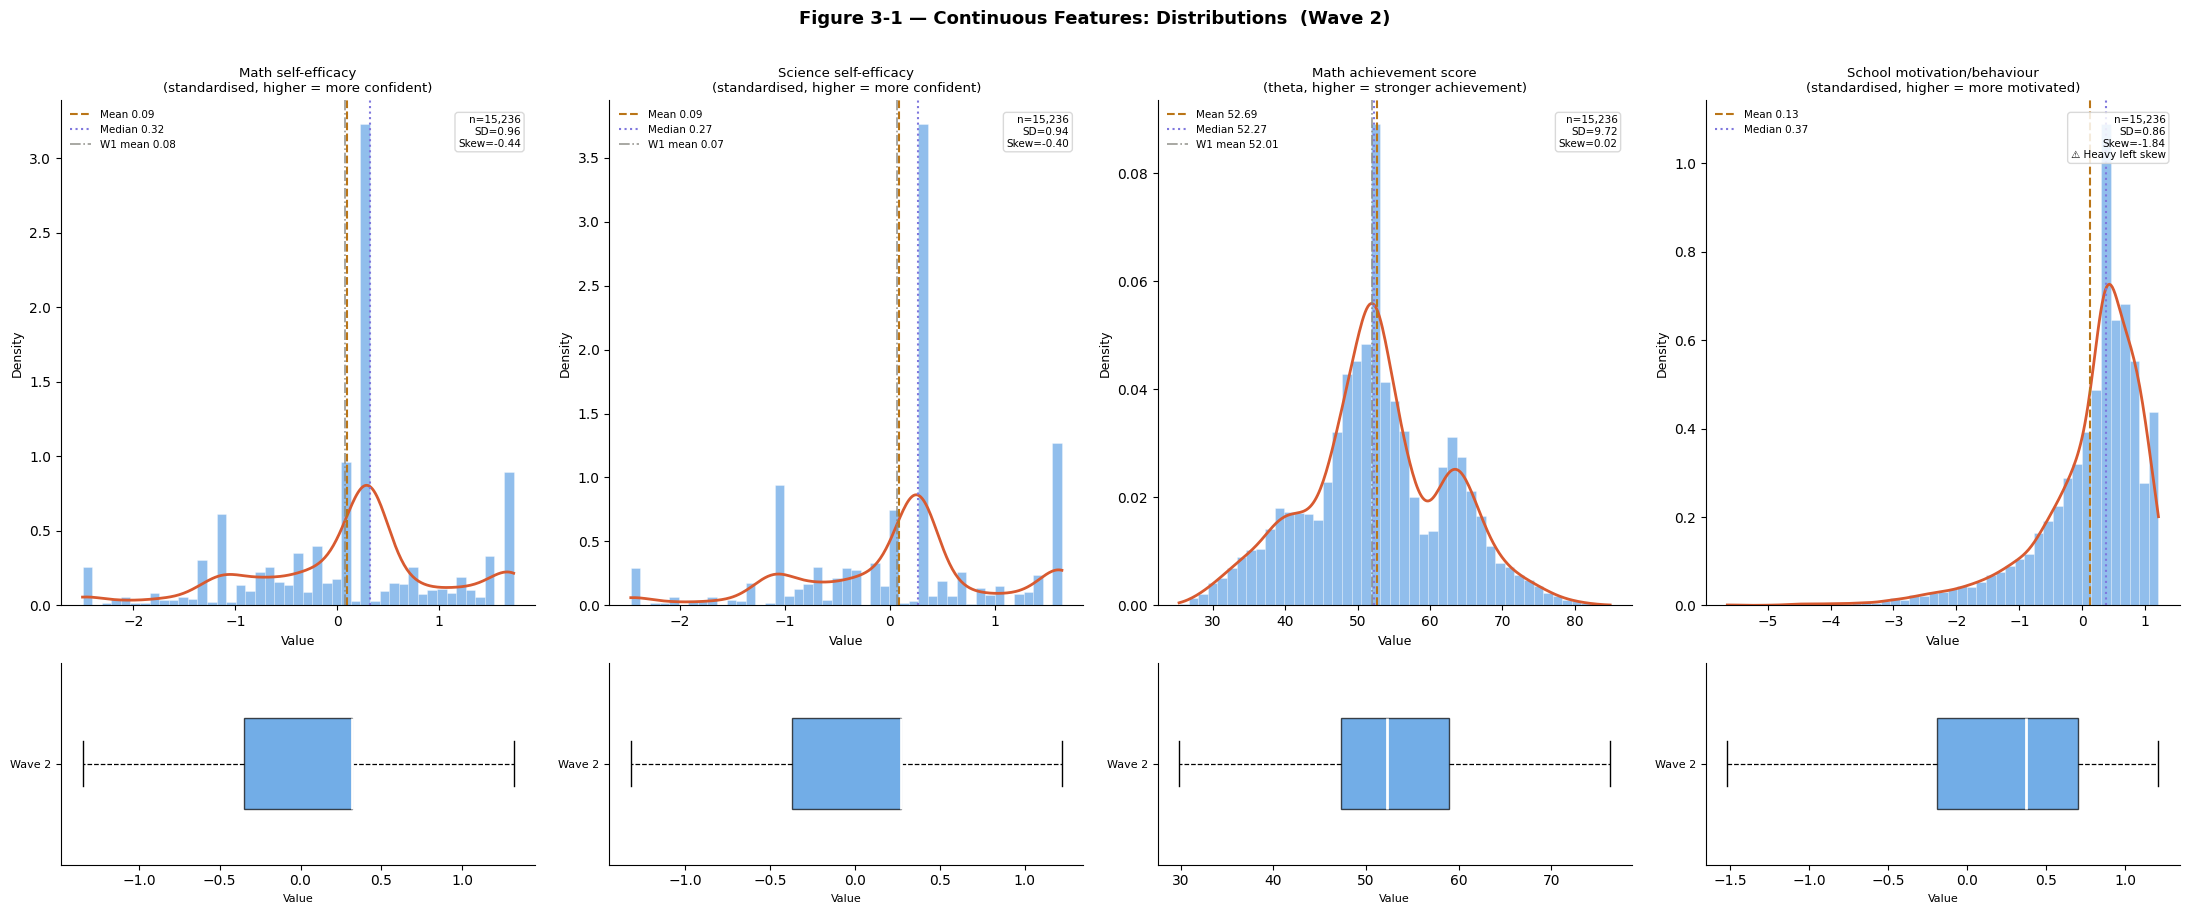

Saved → w2_step3_fig1_continuous.png


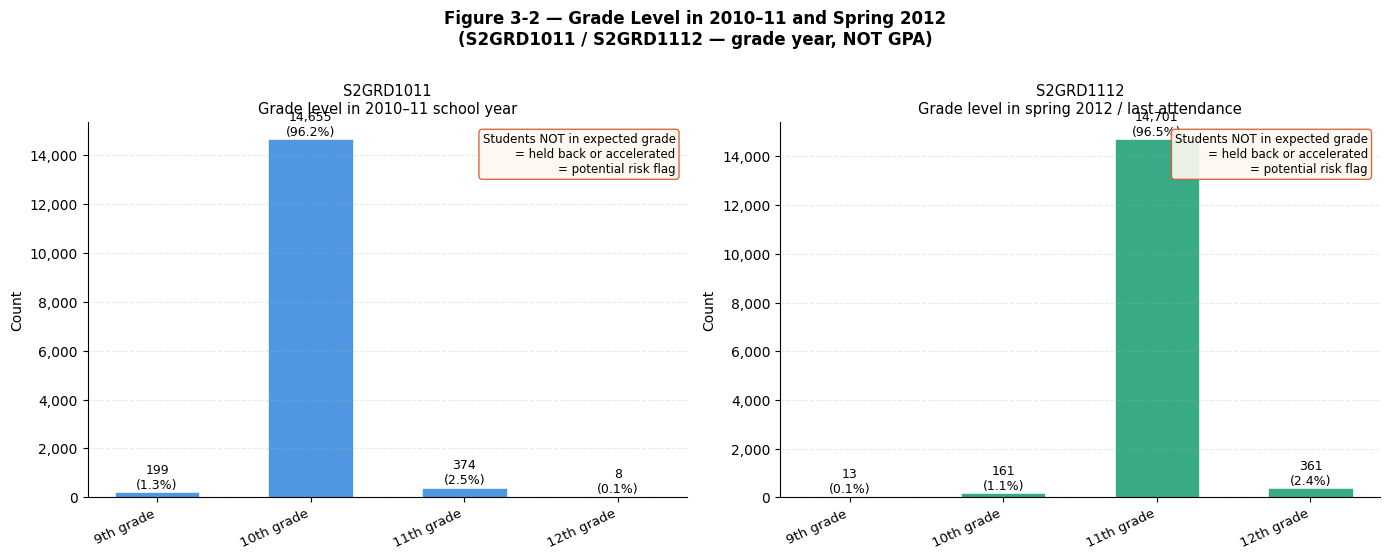

Saved → w2_step3_fig2_gradelevel.png


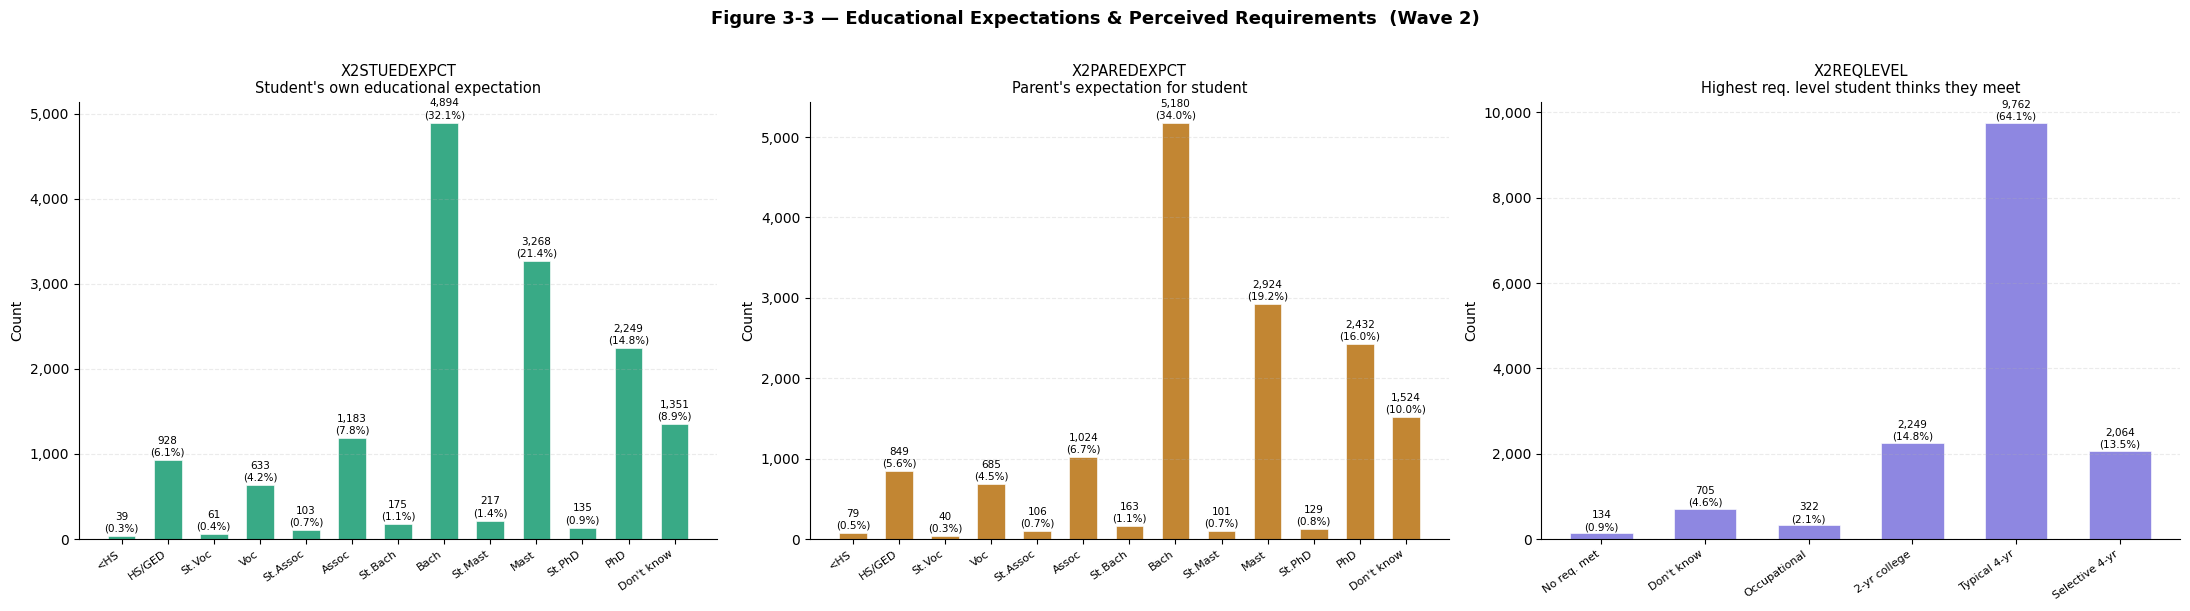

Saved → w2_step3_fig3_expectations.png


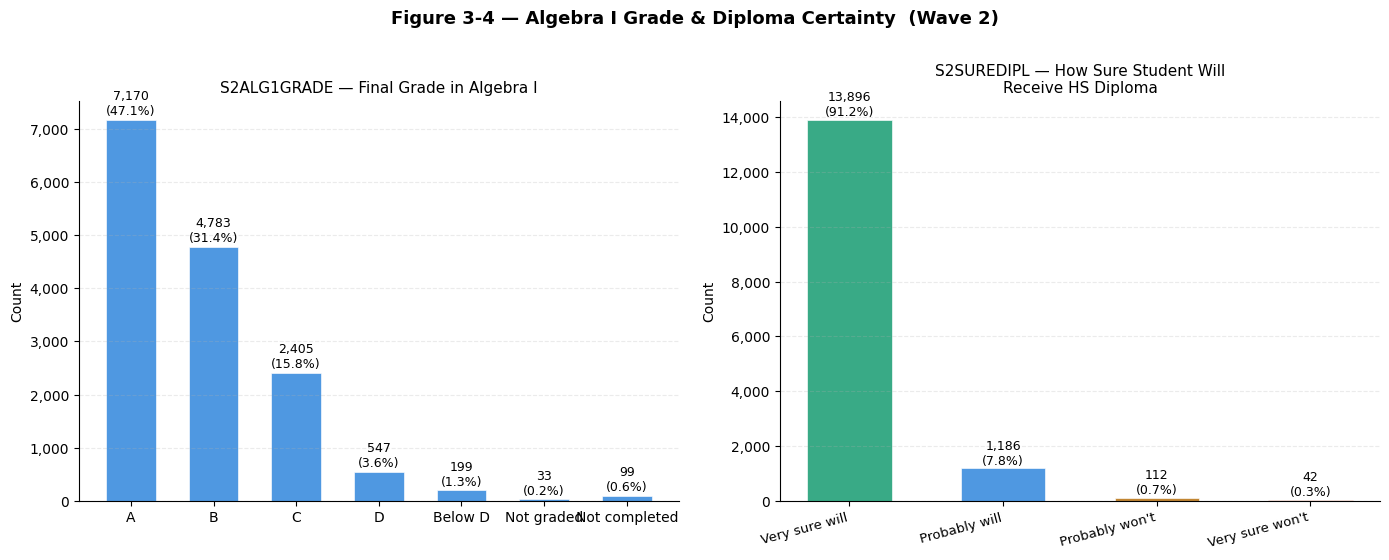

Saved → w2_step3_fig4_alg_diploma.png


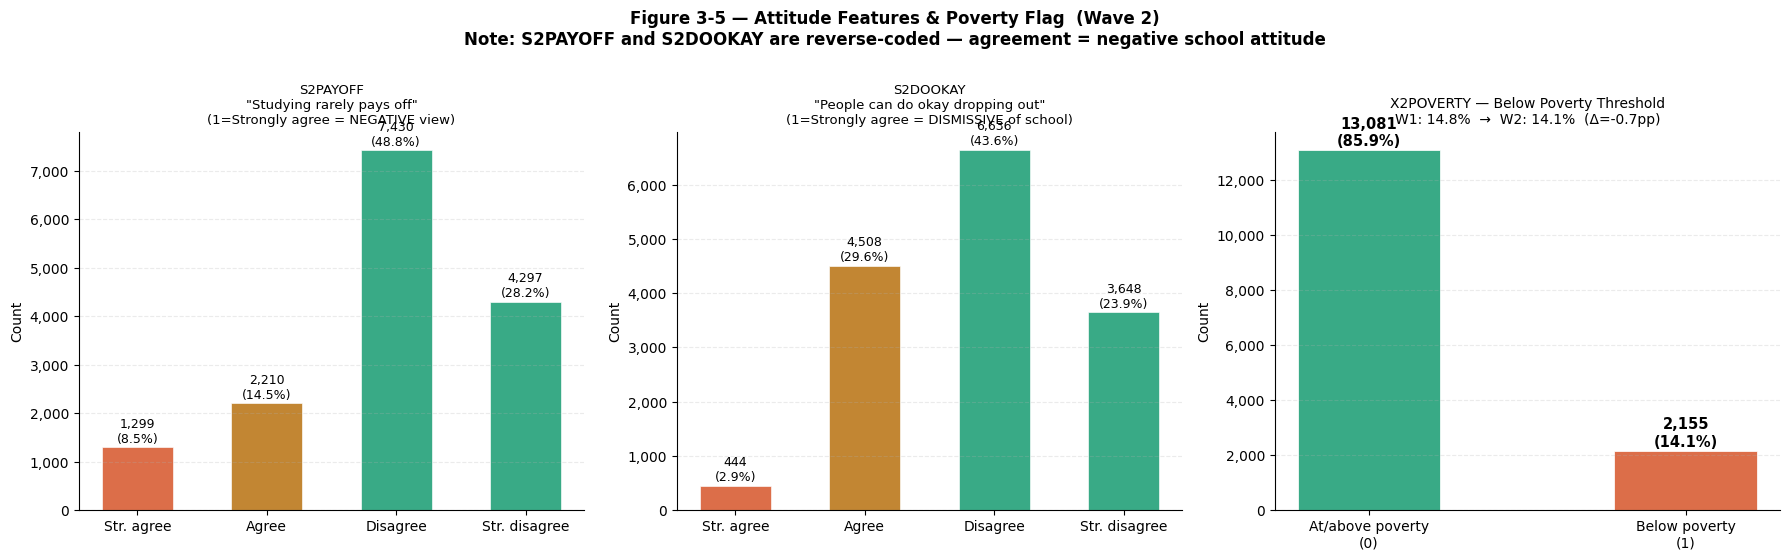

Saved → w2_step3_fig5_attitudes_poverty.png

  UNIVARIATE SUMMARY — WAVE 2 (CORRECTED)

--- Continuous ---
  X2MTHEFF        : mean=0.09, sd=0.96, skew=-0.44  [W1 mean=0.08, Δ=+0.01]
  X2SCIEFF        : mean=0.09, sd=0.94, skew=-0.40  [W1 mean=0.07, Δ=+0.02]
  X2TXMTSCOR      : mean=52.69, sd=9.72, skew=0.02  [W1 mean=52.01, Δ=+0.68]
  X2BEHAVEIN      : mean=0.13, sd=0.86, skew=-1.84

--- Grade Level (S2GRD1011 / S2GRD1112) ---
  S2GRD1011 9th grade     : 199 (1.3%)
  S2GRD1011 10th grade    : 14,655 (96.2%)
  S2GRD1011 11th grade    : 374 (2.5%)
  S2GRD1011 12th grade    : 8 (0.1%)
  S2GRD1112 9th grade     : 13 (0.1%)
  S2GRD1112 10th grade    : 161 (1.1%)
  S2GRD1112 11th grade    : 14,701 (96.5%)
  S2GRD1112 12th grade    : 361 (2.4%)

--- Expectations: % by category ---
  X2STUEDEXPCT < HS                          : 39 (0.3%)
  X2STUEDEXPCT HS/GED                        : 928 (6.1%)
  X2STUEDEXPCT Start voc cert                : 61 (0.4%)
  X2PAREDEXPCT < HS                       

In [6]:
# ============================================================
# WAVE 2 EDA — STEP 3 (CORRECTED)
# Univariate Distributions
# All labels and interpretations based on HSLS codebook
# ============================================================

C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

# Wave 1 reference stats (from EDA notebook)
W1_REF = {
    "X1MTHEFF"  : dict(mean=0.08,  sd=0.98, skew=-0.38),
    "X1SCIEFF"  : dict(mean=0.07,  sd=0.97, skew=-0.24),
    "X1TXMTSCOR": dict(mean=52.01, sd=10.01, skew=-0.06),
    "X1POVERTY" : dict(pct_yes=14.8),
}
W1_PAIRS = {
    "X2MTHEFF"   : "X1MTHEFF",
    "X2SCIEFF"   : "X1SCIEFF",
    "X2TXMTSCOR" : "X1TXMTSCOR",
}

# ── Codebook label maps ───────────────────────────────────────
# S2GRD1011 / S2GRD1112 — GRADE LEVEL, not GPA
grade_level_labels = {
    1: "9th grade",
    2: "10th grade",
    3: "11th grade",
    4: "12th grade",
    5: "Ungraded",
    6: "Not attending",
}

# X2PAREDEXPCT / X2STUEDEXPCT
expect_labels = {
    1:  "< HS",
    2:  "HS/GED",
    3:  "Start voc cert",
    4:  "Complete voc cert",
    5:  "Start Associate's",
    6:  "Complete Associate's",
    7:  "Start Bachelor's",
    8:  "Complete Bachelor's",
    9:  "Start Master's",
    10: "Complete Master's",
    11: "Start PhD/Prof",
    12: "Complete PhD/Prof",
    13: "Don't know",
}
expect_short = {
    1:"<HS", 2:"HS/GED", 3:"St.Voc", 4:"Voc",
    5:"St.Assoc", 6:"Assoc", 7:"St.Bach", 8:"Bach",
    9:"St.Mast", 10:"Mast", 11:"St.PhD", 12:"PhD",
    13:"Don't know",
}

# X2REQLEVEL
reqlevel_labels = {
    0: "No req. met",
    1: "Don't know",
    2: "Occupational",
    3: "2-yr college",
    4: "Typical 4-yr",
    5: "Selective 4-yr",
}

# S2SUREDIPL
suredipl_labels = {
    1: "Very sure will",
    2: "Probably will",
    3: "Probably won't",
    4: "Very sure won't",
}

# S2ALG1GRADE
alg1_labels = {
    1: "A",
    2: "B",
    3: "C",
    4: "D",
    5: "Below D",
    6: "Not graded",
    7: "Not completed",
}

# S2PAYOFF — "Studying rarely pays off"
# 1=Strongly agree (NEGATIVE attitude) → 4=Strongly disagree (POSITIVE)
payoff_labels = {
    1: "Str. agree\n(school no payoff)",
    2: "Agree",
    3: "Disagree",
    4: "Str. disagree\n(school pays off)",
}
payoff_short = {1:"Str. agree", 2:"Agree",
                3:"Disagree",  4:"Str. disagree"}

# S2DOOKAY — "People can do okay even if they drop out"
# 1=Strongly agree (DISMISSIVE of staying) → 4=Strongly disagree
dookay_labels = {
    1: "Str. agree\n(dropout okay)",
    2: "Agree",
    3: "Disagree",
    4: "Str. disagree\n(dropout NOT okay)",
}
dookay_short = {1:"Str. agree", 2:"Agree",
                3:"Disagree",  4:"Str. disagree"}


# ─────────────────────────────────────────────────────────────
# FIGURE 3-1  Continuous Features
# ─────────────────────────────────────────────────────────────
continuous = {
    "X2MTHEFF"   : "Math self-efficacy\n(standardised, higher = more confident)",
    "X2SCIEFF"   : "Science self-efficacy\n(standardised, higher = more confident)",
    "X2TXMTSCOR" : "Math achievement score\n(theta, higher = stronger achievement)",
    "X2BEHAVEIN" : "School motivation/behaviour\n(standardised, higher = more motivated)",
}

fig1, axes = plt.subplots(2, 4, figsize=(22, 9),
                           gridspec_kw={"height_ratios": [2.5, 1]})
fig1.suptitle(
    "Figure 3-1 — Continuous Features: Distributions  (Wave 2)",
    fontsize=13, fontweight="bold", y=1.01)

for j, (col, label) in enumerate(continuous.items()):
    ax_hist = axes[0, j]
    ax_box  = axes[1, j]
    data    = df[col].dropna()

    ax_hist.hist(data, bins=45, color=C_BLUE, alpha=0.55,
                 edgecolor="white", linewidth=0.4, density=True)
    kde = gaussian_kde(data, bw_method=0.2)
    xr  = np.linspace(data.min(), data.max(), 300)
    ax_hist.plot(xr, kde(xr), color=C_CORAL, linewidth=2)
    ax_hist.axvline(data.mean(),   color=C_AMBER, linestyle="--",
                    linewidth=1.5, label=f"Mean {data.mean():.2f}")
    ax_hist.axvline(data.median(), color=C_PURP,  linestyle=":",
                    linewidth=1.5, label=f"Median {data.median():.2f}")

    # Wave 1 mean overlay
    w1_key = W1_PAIRS.get(col)
    if w1_key:
        w1_mean = W1_REF[w1_key]["mean"]
        ax_hist.axvline(w1_mean, color=C_GRAY, linestyle="-.",
                        linewidth=1.2, alpha=0.85,
                        label=f"W1 mean {w1_mean:.2f}")

    stats_txt = (f"n={len(data):,}\n"
                 f"SD={data.std():.2f}\n"
                 f"Skew={data.skew():.2f}")
    if col == "X2BEHAVEIN":
        stats_txt += "\n⚠ Heavy left skew"
    ax_hist.text(0.97, 0.97, stats_txt,
                 transform=ax_hist.transAxes,
                 fontsize=7.5, va="top", ha="right",
                 bbox=dict(boxstyle="round,pad=0.3",
                           fc="white", ec="lightgray", alpha=0.85))

    ax_hist.set_title(label, fontsize=9.5)
    ax_hist.set_xlabel("Value", fontsize=9)
    ax_hist.set_ylabel("Density", fontsize=9)
    ax_hist.spines[["top","right"]].set_visible(False)
    ax_hist.legend(fontsize=7.5, frameon=False)

    bp = ax_box.boxplot([data], vert=False, patch_artist=True,
                         widths=0.45, showfliers=False,
                         medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor(C_BLUE)
    bp["boxes"][0].set_alpha(0.7)
    for w in bp["whiskers"]:
        w.set(linestyle="--", linewidth=0.9)
    ax_box.set_yticks([1])
    ax_box.set_yticklabels(["Wave 2"], fontsize=8)
    ax_box.set_xlabel("Value", fontsize=8)
    ax_box.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("w2_step3_fig1_continuous.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step3_fig1_continuous.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 3-2  Grade Level Progression (S2GRD1011 / S2GRD1112)
# NOT GPA — these are year-of-school variables
# ─────────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig2.suptitle(
    "Figure 3-2 — Grade Level in 2010–11 and Spring 2012\n"
    "(S2GRD1011 / S2GRD1112 — grade year, NOT GPA)",
    fontsize=12, fontweight="bold", y=1.01)

grade_specs = [
    ("S2GRD1011", "S2GRD1011\nGrade level in 2010–11 school year",   C_BLUE),
    ("S2GRD1112", "S2GRD1112\nGrade level in spring 2012 / last attendance", C_TEAL),
]

for ax, (col, title, color) in zip(axes, grade_specs):
    vc   = df[col].value_counts().sort_index()
    keys = [k for k in vc.index if k in grade_level_labels]
    vals = [vc[k] for k in keys]
    lbls = [grade_level_labels[k] for k in keys]
    pcts = [v/len(df)*100 for v in vals]

    bars = ax.bar(lbls, vals, color=color, edgecolor="white",
                  linewidth=0.5, width=0.55, alpha=0.88)
    for bar, cnt, pct in zip(bars, vals, pcts):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+50,
                f"{cnt:,}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=9)

    # Annotate the off-track students
    ax.text(0.98, 0.97,
            "Students NOT in expected grade\n"
            "= held back or accelerated\n"
            "= potential risk flag",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="#FFF8F0",
                      ec=C_CORAL, alpha=0.9))

    ax.set_title(title, fontsize=10.5)
    ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9.5)

plt.tight_layout()
plt.savefig("w2_step3_fig2_gradelevel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step3_fig2_gradelevel.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 3-3  Educational Expectations
# (X2PAREDEXPCT, X2STUEDEXPCT, X2REQLEVEL)
# ─────────────────────────────────────────────────────────────
fig3, axes = plt.subplots(1, 3, figsize=(22, 6))
fig3.suptitle(
    "Figure 3-3 — Educational Expectations & Perceived Requirements  (Wave 2)",
    fontsize=13, fontweight="bold", y=1.01)

expect_specs = [
    ("X2STUEDEXPCT",
     "X2STUEDEXPCT\nStudent's own educational expectation",
     expect_short, C_TEAL),
    ("X2PAREDEXPCT",
     "X2PAREDEXPCT\nParent's expectation for student",
     expect_short, C_AMBER),
    ("X2REQLEVEL",
     "X2REQLEVEL\nHighest req. level student thinks they meet",
     reqlevel_labels, C_PURP),
]

for ax, (col, title, lmap, color) in zip(axes, expect_specs):
    vc   = df[col].value_counts().sort_index()
    keys = [k for k in vc.index if k in lmap]
    vals = [vc[k] for k in keys]
    pcts = [v/len(df)*100 for v in vals]

    bars = ax.bar([lmap[k] for k in keys], vals,
                  color=color, edgecolor="white",
                  linewidth=0.5, width=0.6, alpha=0.88)
    for bar, cnt, pct in zip(bars, vals, pcts):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+30,
                f"{cnt:,}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=7.5)

    ax.set_title(title, fontsize=10.5)
    ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("w2_step3_fig3_expectations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step3_fig3_expectations.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 3-4  Academic Performance & Certainty
# (S2ALG1GRADE, S2SUREDIPL)
# ─────────────────────────────────────────────────────────────
fig4, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig4.suptitle(
    "Figure 3-4 — Algebra I Grade & Diploma Certainty  (Wave 2)",
    fontsize=13, fontweight="bold", y=1.01)

# S2ALG1GRADE
ax = axes[0]
vc   = df["S2ALG1GRADE"].value_counts().sort_index()
keys = [k for k in vc.index if k in alg1_labels]
vals = [vc[k] for k in keys]
pcts = [v/len(df)*100 for v in vals]
bars = ax.bar([alg1_labels[k] for k in keys], vals,
              color=C_BLUE, edgecolor="white",
              linewidth=0.5, width=0.6, alpha=0.88)
for bar, cnt, pct in zip(bars, vals, pcts):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+40,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("S2ALG1GRADE — Final Grade in Algebra I", fontsize=11)
ax.set_ylabel("Count")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# S2SUREDIPL
ax = axes[1]
vc   = df["S2SUREDIPL"].value_counts().sort_index()
keys = [k for k in vc.index if k in suredipl_labels]
vals = [vc[k] for k in keys]
pcts = [v/len(df)*100 for v in vals]
bar_colors = [C_TEAL, C_BLUE, C_AMBER, C_CORAL]
bars = ax.bar([suredipl_labels[k] for k in keys], vals,
              color=bar_colors[:len(keys)],
              edgecolor="white", linewidth=0.5, width=0.55, alpha=0.88)
for bar, cnt, pct in zip(bars, vals, pcts):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+40,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("S2SUREDIPL — How Sure Student Will\nReceive HS Diploma", fontsize=11)
ax.set_ylabel("Count")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=9.5)

plt.tight_layout()
plt.savefig("w2_step3_fig4_alg_diploma.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step3_fig4_alg_diploma.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 3-5  Attitude features (REVERSE CODED — corrected)
# S2PAYOFF: "Studying rarely pays off" — agree = NEGATIVE attitude
# S2DOOKAY: "Can do okay dropping out" — agree = DISMISSIVE
# ─────────────────────────────────────────────────────────────
fig5, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig5.suptitle(
    "Figure 3-5 — Attitude Features & Poverty Flag  (Wave 2)\n"
    "Note: S2PAYOFF and S2DOOKAY are reverse-coded — "
    "agreement = negative school attitude",
    fontsize=12, fontweight="bold", y=1.01)

# S2PAYOFF — "Studying rarely pays off"
ax = axes[0]
vc   = df["S2PAYOFF"].value_counts().sort_index()
keys = [k for k in vc.index if k in payoff_short]
vals = [vc[k] for k in keys]
pcts = [v/len(df)*100 for v in vals]
# Color: agree=red (negative), disagree=green (positive)
bar_cols = [C_CORAL, C_AMBER, C_TEAL, C_TEAL]
bars = ax.bar([payoff_short[k] for k in keys], vals,
              color=bar_cols[:len(keys)], edgecolor="white",
              linewidth=0.5, width=0.55, alpha=0.88)
for bar, cnt, pct in zip(bars, vals, pcts):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+40,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title('S2PAYOFF\n"Studying rarely pays off"\n'
             '(1=Strongly agree = NEGATIVE view)',
             fontsize=9.5)
ax.set_ylabel("Count")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# S2DOOKAY — "Can do okay dropping out"
ax = axes[1]
vc   = df["S2DOOKAY"].value_counts().sort_index()
keys = [k for k in vc.index if k in dookay_short]
vals = [vc[k] for k in keys]
pcts = [v/len(df)*100 for v in vals]
bars = ax.bar([dookay_short[k] for k in keys], vals,
              color=bar_cols[:len(keys)], edgecolor="white",
              linewidth=0.5, width=0.55, alpha=0.88)
for bar, cnt, pct in zip(bars, vals, pcts):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+40,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title('S2DOOKAY\n"People can do okay dropping out"\n'
             '(1=Strongly agree = DISMISSIVE of school)',
             fontsize=9.5)
ax.set_ylabel("Count")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# X2POVERTY — with Wave 1 comparison
ax = axes[2]
pov_w2_yes = int((df["X2POVERTY"]==1).sum())
pov_w2_no  = int((df["X2POVERTY"]==0).sum())
pov_w2_pct = pov_w2_yes / len(df) * 100
pov_w1_pct = W1_REF["X1POVERTY"]["pct_yes"]

bars_p = ax.bar(["At/above poverty\n(0)", "Below poverty\n(1)"],
                [pov_w2_no, pov_w2_yes],
                color=[C_TEAL, C_CORAL],
                edgecolor="white", linewidth=0.6,
                width=0.45, alpha=0.88)
for bar, cnt, pct in zip(bars_p,
                          [pov_w2_no, pov_w2_yes],
                          [100-pov_w2_pct, pov_w2_pct]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+60,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10.5, fontweight="bold")
ax.set_title(f"X2POVERTY — Below Poverty Threshold\n"
             f"W1: {pov_w1_pct:.1f}%  →  W2: {pov_w2_pct:.1f}%  "
             f"(Δ={pov_w2_pct-pov_w1_pct:+.1f}pp)",
             fontsize=10)
ax.set_ylabel("Count")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("w2_step3_fig5_attitudes_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step3_fig5_attitudes_poverty.png")


# ─────────────────────────────────────────────────────────────
# PRINTED SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*62)
print("  UNIVARIATE SUMMARY — WAVE 2 (CORRECTED)")
print("="*62)

print("\n--- Continuous ---")
for col in continuous:
    d = df[col].dropna()
    w1_key = W1_PAIRS.get(col)
    delta_note = ""
    if w1_key:
        delta = d.mean() - W1_REF[w1_key]["mean"]
        delta_note = f"  [W1 mean={W1_REF[w1_key]['mean']:.2f}, Δ={delta:+.2f}]"
    print(f"  {col:<16}: mean={d.mean():.2f}, sd={d.std():.2f}, "
          f"skew={d.skew():.2f}{delta_note}")

print("\n--- Grade Level (S2GRD1011 / S2GRD1112) ---")
for col in ["S2GRD1011", "S2GRD1112"]:
    vc = df[col].value_counts().sort_index()
    for k, v in vc.items():
        if k in grade_level_labels:
            print(f"  {col} {grade_level_labels[k]:<14}: "
                  f"{v:,} ({v/len(df)*100:.1f}%)")

print("\n--- Expectations: % by category ---")
for col in ["X2STUEDEXPCT", "X2PAREDEXPCT"]:
    vc = df[col].value_counts().sort_index()
    top3 = vc.head(3)
    for k, v in top3.items():
        print(f"  {col} {expect_labels.get(k,'?'):<30}: "
              f"{v:,} ({v/len(df)*100:.1f}%)")

print("\n--- Algebra I Grade ---")
vc = df["S2ALG1GRADE"].value_counts().sort_index()
for k, v in vc.items():
    if k in alg1_labels:
        print(f"  {alg1_labels[k]:<14}: {v:,} ({v/len(df)*100:.1f}%)")

print("\n--- Diploma Certainty ---")
vc = df["S2SUREDIPL"].value_counts().sort_index()
for k, v in vc.items():
    if k in suredipl_labels:
        print(f"  {suredipl_labels[k]:<20}: {v:,} ({v/len(df)*100:.1f}%)")

print("\n--- Attitudes (reverse coded) ---")
for col, lmap, stmt in [
    ("S2PAYOFF", payoff_short, "Studying rarely pays off"),
    ("S2DOOKAY", dookay_short, "Can do okay dropping out"),
]:
    print(f"\n  {col} — '{stmt}':")
    vc = df[col].value_counts().sort_index()
    for k, v in vc.items():
        if k in lmap:
            print(f"    {lmap[k]:<14}: {v:,} ({v/len(df)*100:.1f}%)")

print(f"\n--- Binary ---")
pov_pct = (df["X2POVERTY"]==1).sum()/len(df)*100
print(f"  X2POVERTY: {pov_pct:.1f}% below poverty "
      f"[W1: {pov_w1_pct:.1f}%, Δ={pov_pct-pov_w1_pct:+.1f}pp]")

## Key Takeaways — Step 3: Univariate Distributions

**Figure 3-1 — Continuous features:**
- `X2MTHEFF`, `X2SCIEFF`, and `X2TXMTSCOR` are near-identical to their
  Wave 1 counterparts in shape and mean — the same constructs measured
  two years later. Students' academic self-perception and achievement
  are largely stable at the population level from 9th to 11th grade.
- `X2BEHAVEIN` (school motivation/behaviour) is the most distinctive
  feature in the dataset: skew = −1.84, the heaviest left tail of any
  variable. Most students are moderately motivated; a small but
  meaningful disengaged minority pulls the distribution hard left.
  This tail is where dropout risk concentrates.

**Figure 3-2 — Grade level (S2GRD1011 / S2GRD1112):**
- These are NOT GPA — they record which year of high school the student
  was in. The expected pattern: ~96% in 10th grade during 2010–11
  (S2GRD1011=2) and ~96% in 11th grade in spring 2012 (S2GRD1112=3).
- The analytically interesting students are the ~4% who deviate:
  those still in 9th grade in 2010–11 are held back (behind schedule),
  those in 11th or 12th are accelerated. Grade retention is a known
  strong dropout predictor — the small held-back group warrants
  attention in the bivariate step.

**Figure 3-3 — Educational expectations:**
- `X2STUEDEXPCT`: "Complete Bachelor's" is the single largest category
  (32.2%), followed by "Don't know" (16.2%) and "Complete Master's"
  (19.2%). The large "Don't know" group — now in 11th grade — signals
  persistent uncertainty at a stage where most students should have
  clearer aspirations.
- `X2PAREDEXPCT`: "Complete Bachelor's" (34.1%) dominates, but "Don't
  know" remains sizeable (10.0%). Parents broadly expect college
  completion, but a meaningful minority remain uncertain.
- `X2REQLEVEL`: most students (64.1%) believe they meet the requirements
  for a typical 4-year college — this is a self-assessed confidence
  measure, not an objective placement. Students who answered "No req.
  met" or "Don't know" are likely the highest-risk subgroup here.

**Figure 3-4 — Algebra grade & diploma certainty:**
- `S2ALG1GRADE`: A (47.1%) and B (31.4%) dominate, with a meaningful
  tail of C (15.8%), D/below D (3.6%), and not completed (0.6%).
  This is a well-spread ordinal variable with enough variance across
  all categories to be informative.
- `S2SUREDIPL`: 91.2% "Very sure will" receive their diploma — the most
  concentrated variable in the dataset. The 8.8% who answered
  "Probably will", "Probably won't", or "Very sure won't" carry
  nearly all the predictive weight. The "Very sure won't" group
  (n ≈ 42) is likely an extremely high-risk micro-segment.

**Figure 3-5 — Attitudes (corrected interpretation):**
- `S2PAYOFF`: Most students disagree or strongly disagree that school
  rarely pays off — meaning most hold a positive view of school's
  value. The 8.5% who Strongly Agree (school has no payoff) are the
  at-risk minority. Direction: higher code = more positive attitude.
- `S2DOOKAY`: 29.4% Strongly Agree that people can do okay dropping
  out — this is a large dismissive-of-school group. Unlike S2PAYOFF,
  this attitude is more evenly distributed, wit

## Hypotheses

1. **The held-back students in S2GRD1011 (still in 9th grade in 2010–11)
   will show dramatically elevated dropout rates in Step 4.** Grade
   retention is one of the most robust dropout predictors in the
   education literature. Even though this group is tiny (~4%), it
   should produce one of the largest dropout rate gaps in the
   bivariate analysis.

2. **`X2BEHAVEIN`'s disengaged left tail will be the strongest
   continuous predictor.** The skew means a small group of students
   is deeply unmotivated — and being deeply unmotivated in 11th grade
   is a late-stage warning signal far closer in time to the dropout
   event than anything measured in Wave 1.

3. **`S2DOOKAY` will be more predictive than `S2PAYOFF`.** With 29.4%
   of students agreeing that dropout is acceptable, this attitude
   variable has more variance and a more direct logical link to the
   outcome. `S2PAYOFF` (8.5% with negative view) is too concentrated
   in the "school is worth it" response to carry much signal.

4. **The "Don't know" category in `X2STUEDEXPCT` will show elevated
   dropout risk.** Reaching 11th grade with no clear educational
   expectation is qualitatively different from the same uncertainty
   in 9th grade — it represents two years of non-crystallization
   during a critical planning window, which we expect to correlate
   with eventual disengagement and dropout.

# EDA - STEP 4: Bivariate Analysis (Feature vs. Target).

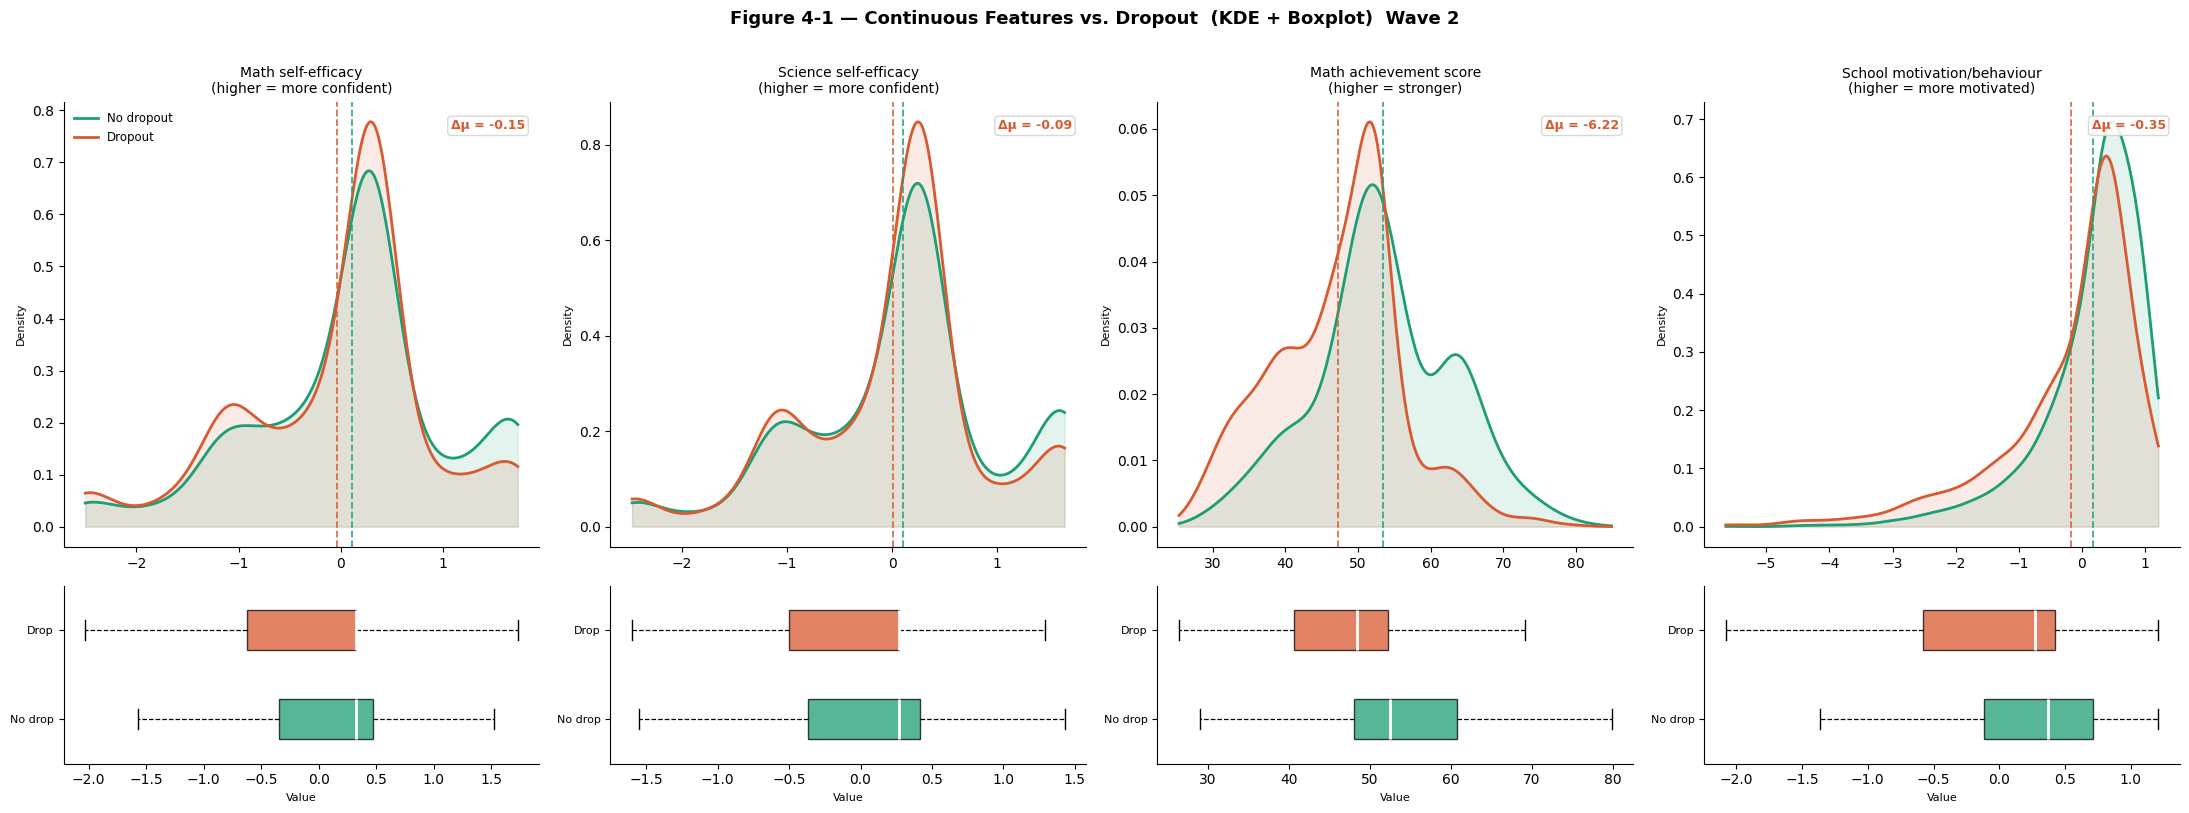

Saved → w2_step4_fig1_continuous_bivariate.png


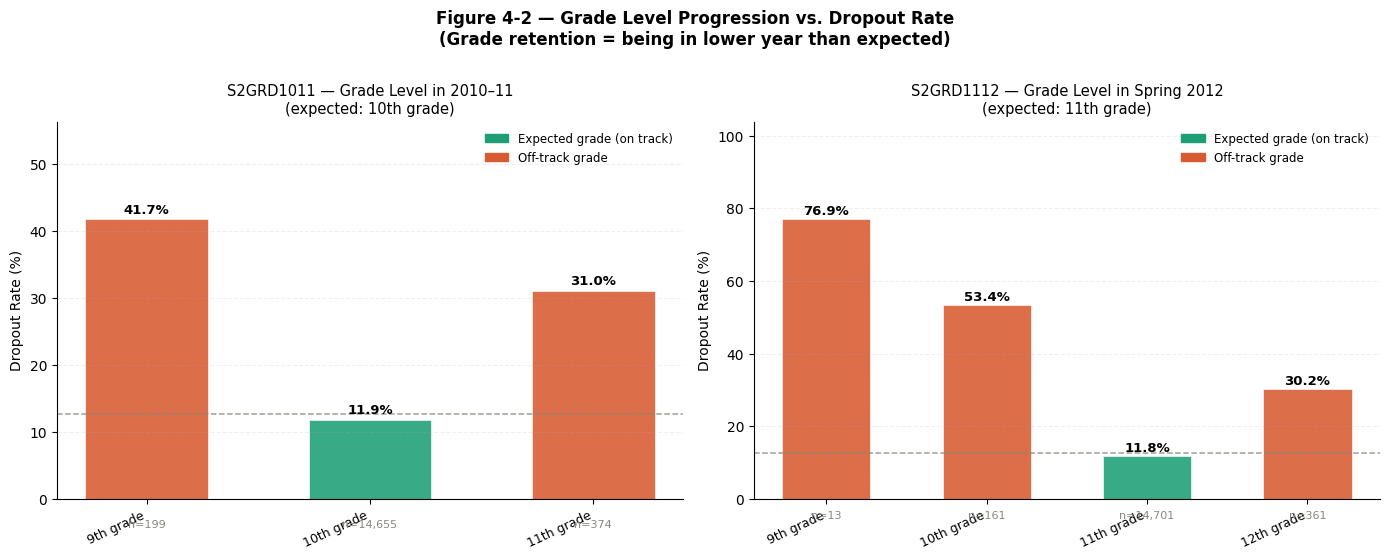

Saved → w2_step4_fig2_gradelevel_bivariate.png


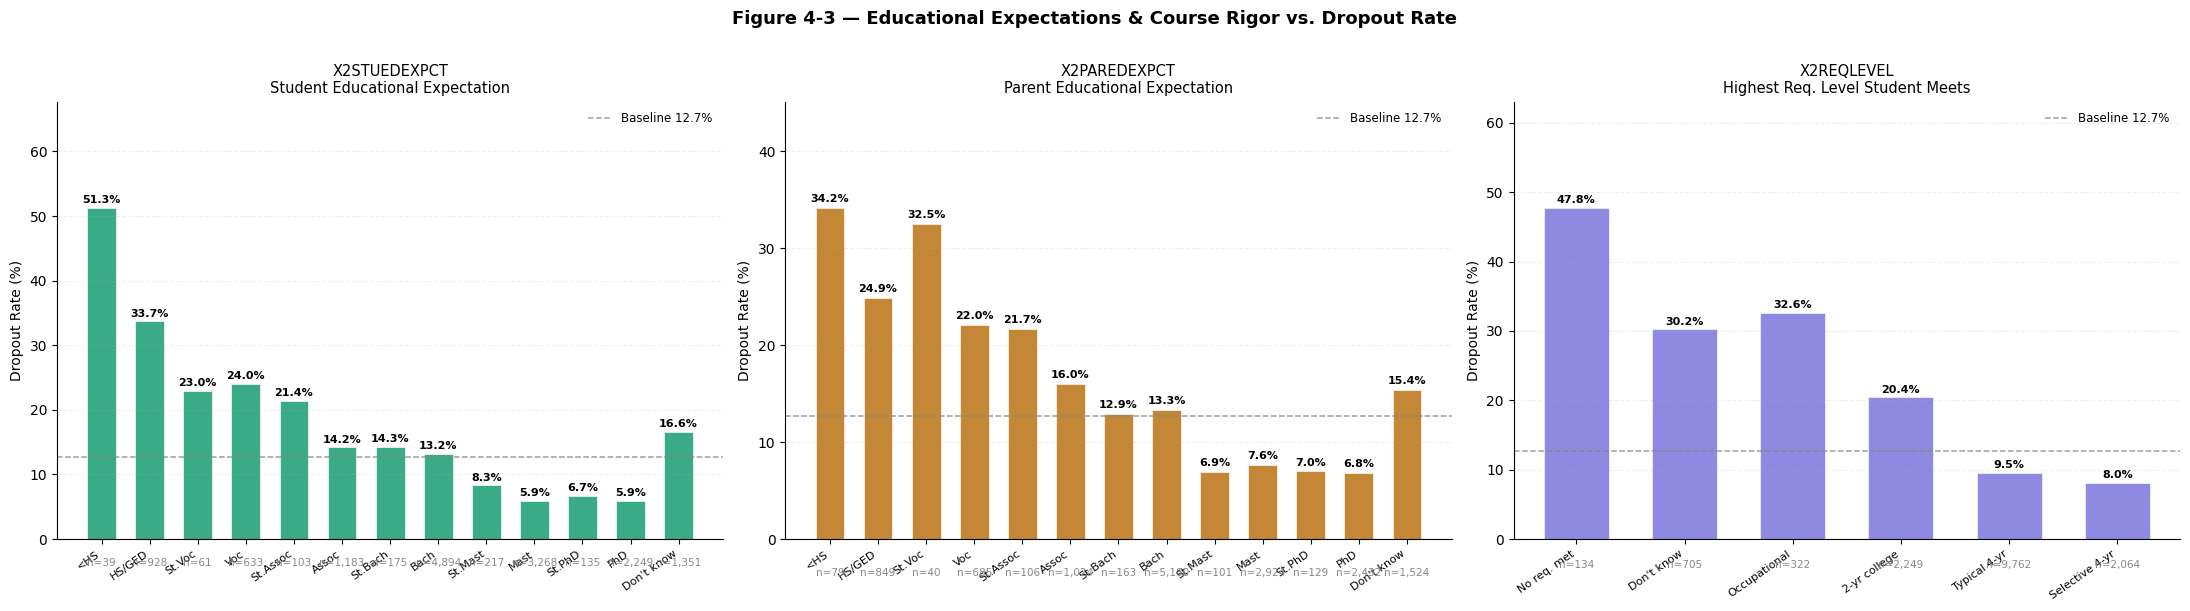

Saved → w2_step4_fig3_expectations_bivariate.png


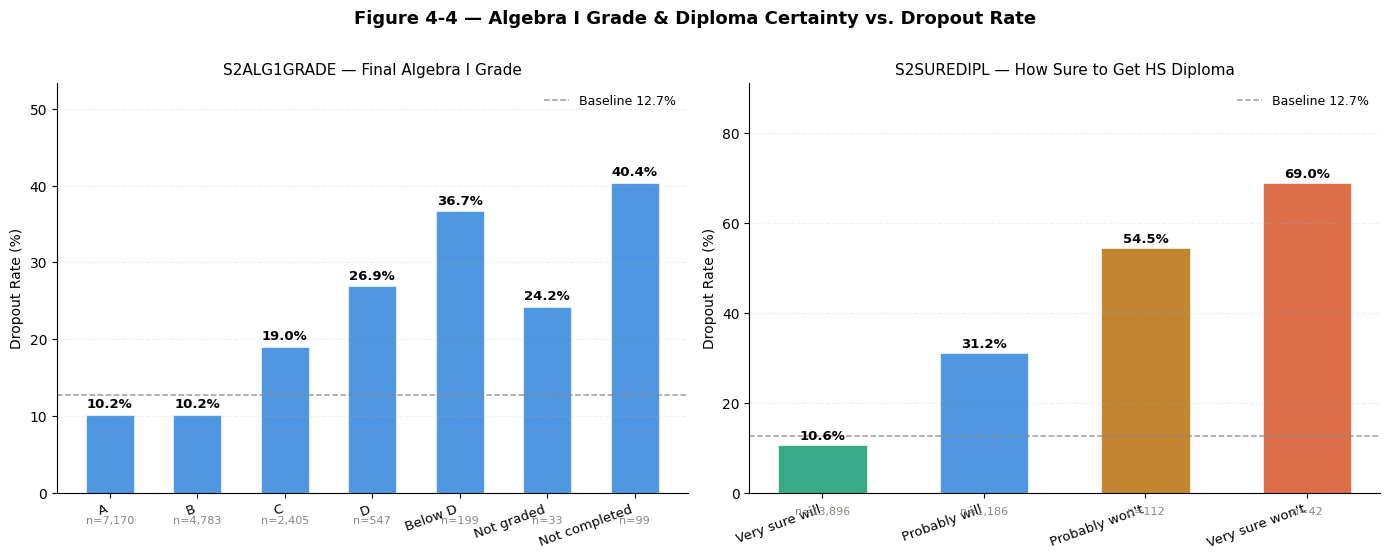

Saved → w2_step4_fig4_alg_diploma_bivariate.png


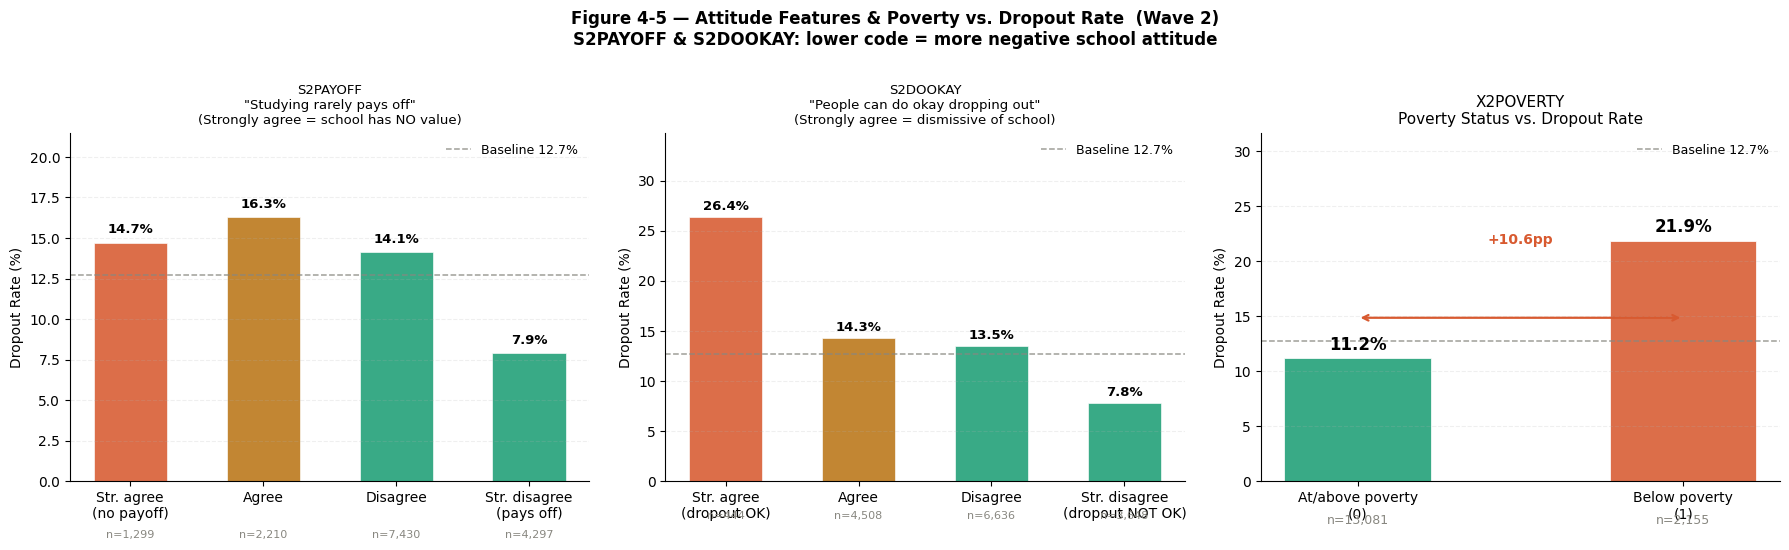

Saved → w2_step4_fig5_attitudes_poverty_bivariate.png

  STEP 4 — BIVARIATE SUMMARY  (Wave 2, corrected)
  Baseline dropout rate: 12.73%

--- Continuous: Δμ and point-biserial r ---
  X2MTHEFF        : μ_drop=-0.04  μ_nodrop=0.11  Δ=-0.15  r=-0.052  p=<0.001
  X2SCIEFF        : μ_drop=0.01  μ_nodrop=0.10  Δ=-0.09  r=-0.033  p=<0.001
  X2TXMTSCOR      : μ_drop=47.26  μ_nodrop=53.48  Δ=-6.22  r=-0.213  p=<0.001
  X2BEHAVEIN      : μ_drop=-0.17  μ_nodrop=0.17  Δ=-0.35  r=-0.135  p=<0.001

--- Ordinal: dropout rate range across categories ---
  S2GRD1011       : max=41.7% (9th grade)  min=11.9% (10th grade)  range=29.8pp  r=0.012
  S2GRD1112       : max=53.4% (10th grade)  min=11.8% (11th grade)  range=41.6pp  r=-0.010
  X2STUEDEXPCT    : max=51.3% (<HS)  min=5.9% (PhD)  range=45.4pp  r=-0.145
  X2PAREDEXPCT    : max=34.2% (<HS)  min=6.8% (PhD)  range=27.4pp  r=-0.109
  X2REQLEVEL      : max=47.8% (No req. met)  min=8.0% (Selective 4-yr)  range=39.7pp  r=-0.179
  S2ALG1GRADE     : max=40.4

In [8]:
# ============================================================
# WAVE 2 EDA — STEP 4 (CORRECTED)
# Bivariate Analysis — every feature vs X4EVERDROP
# All labels from HSLS codebook; reverse-coded attitudes corrected
# ============================================================

C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

BASE_DR = df["X4EVERDROP"].mean() * 100   # 12.73%

# ── Codebook label maps ───────────────────────────────────────
grade_level_labels = {
    1:"9th grade", 2:"10th grade", 3:"11th grade",
    4:"12th grade", 5:"Ungraded", 6:"Not attending",
}
expect_short = {
    1:"<HS", 2:"HS/GED", 3:"St.Voc", 4:"Voc",
    5:"St.Assoc", 6:"Assoc", 7:"St.Bach", 8:"Bach",
    9:"St.Mast", 10:"Mast", 11:"St.PhD", 12:"PhD",
    13:"Don't know",
}
reqlevel_labels = {
    0:"No req. met", 1:"Don't know", 2:"Occupational",
    3:"2-yr college", 4:"Typical 4-yr", 5:"Selective 4-yr",
}
suredipl_labels = {
    1:"Very sure will", 2:"Probably will",
    3:"Probably won't", 4:"Very sure won't",
}
alg1_labels = {
    1:"A", 2:"B", 3:"C", 4:"D",
    5:"Below D", 6:"Not graded", 7:"Not completed",
}
# Reverse coded — 1=negative attitude, 4=positive attitude
payoff_short = {
    1:"Str. agree\n(no payoff)",
    2:"Agree",
    3:"Disagree",
    4:"Str. disagree\n(pays off)",
}
dookay_short = {
    1:"Str. agree\n(dropout OK)",
    2:"Agree",
    3:"Disagree",
    4:"Str. disagree\n(dropout NOT OK)",
}

def dropout_by_group(col, label_map=None):
    grp = df.groupby(col)["X4EVERDROP"].agg(["mean","count"]).reset_index()
    grp.columns = [col, "rate", "n"]
    grp["rate"] *= 100
    grp["label"] = grp[col].map(label_map) if label_map else grp[col].astype(str)
    return grp


# ─────────────────────────────────────────────────────────────
# FIGURE 4-1  Continuous Features — KDE split + boxplot
# ─────────────────────────────────────────────────────────────
continuous = {
    "X2MTHEFF"   : "Math self-efficacy\n(higher = more confident)",
    "X2SCIEFF"   : "Science self-efficacy\n(higher = more confident)",
    "X2TXMTSCOR" : "Math achievement score\n(higher = stronger)",
    "X2BEHAVEIN" : "School motivation/behaviour\n(higher = more motivated)",
}

fig, axes = plt.subplots(2, 4, figsize=(22, 8),
                          gridspec_kw={"height_ratios": [2.5, 1]})
fig.suptitle(
    "Figure 4-1 — Continuous Features vs. Dropout  (KDE + Boxplot)  Wave 2",
    fontsize=13, fontweight="bold", y=1.01)

for j, (col, label) in enumerate(continuous.items()):
    ax_kde = axes[0, j]
    ax_box = axes[1, j]

    d0  = df.loc[df["X4EVERDROP"]==0, col].dropna()
    d1  = df.loc[df["X4EVERDROP"]==1, col].dropna()
    xr  = np.linspace(min(d0.min(),d1.min()),
                       max(d0.max(),d1.max()), 300)

    for d, color, lbl in [(d0, C_TEAL, "No dropout"),
                           (d1, C_CORAL, "Dropout")]:
        kde = gaussian_kde(d, bw_method=0.25)
        ax_kde.plot(xr, kde(xr), color=color, linewidth=2, label=lbl)
        ax_kde.fill_between(xr, kde(xr), alpha=0.12, color=color)

    ax_kde.axvline(d0.mean(), color=C_TEAL,  linestyle="--",
                   linewidth=1.3, alpha=0.85)
    ax_kde.axvline(d1.mean(), color=C_CORAL, linestyle="--",
                   linewidth=1.3, alpha=0.85)

    delta = d1.mean() - d0.mean()
    sign  = "+" if delta >= 0 else ""
    ax_kde.text(0.97, 0.96,
                f"Δμ = {sign}{delta:.2f}",
                transform=ax_kde.transAxes,
                ha="right", va="top", fontsize=9, fontweight="bold",
                color=C_CORAL if delta < 0 else C_AMBER,
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec="lightgray", alpha=0.88))

    ax_kde.set_title(label, fontsize=10)
    ax_kde.set_ylabel("Density", fontsize=8)
    ax_kde.spines[["top","right"]].set_visible(False)
    if j == 0:
        ax_kde.legend(fontsize=8.5, frameon=False)

    bp = ax_box.boxplot([d0, d1], vert=False, patch_artist=True,
                         widths=0.45, showfliers=False,
                         medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], [C_TEAL, C_CORAL]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for w in bp["whiskers"]:
        w.set(linestyle="--", linewidth=0.9)
    ax_box.set_yticks([1, 2])
    ax_box.set_yticklabels(["No drop", "Drop"], fontsize=8)
    ax_box.set_xlabel("Value", fontsize=8)
    ax_box.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("w2_step4_fig1_continuous_bivariate.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step4_fig1_continuous_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-2  Grade Level vs Dropout Rate
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    "Figure 4-2 — Grade Level Progression vs. Dropout Rate\n"
    "(Grade retention = being in lower year than expected)",
    fontsize=12, fontweight="bold", y=1.01)

for ax, (col, title, color) in zip(axes, [
    ("S2GRD1011", "S2GRD1011 — Grade Level in 2010–11\n"
                  "(expected: 10th grade)", C_BLUE),
    ("S2GRD1112", "S2GRD1112 — Grade Level in Spring 2012\n"
                  "(expected: 11th grade)", C_TEAL),
]):
    grp  = dropout_by_group(col, grade_level_labels)
    grp  = grp[grp["n"] >= 10]

    # Highlight expected grade vs off-track
    bar_cols = []
    for lbl in grp["label"]:
        if "10th" in lbl and "1011" in col: bar_cols.append(C_TEAL)
        elif "11th" in lbl and "1112" in col: bar_cols.append(C_TEAL)
        else: bar_cols.append(C_CORAL)

    bars = ax.bar(grp["label"], grp["rate"],
                  color=bar_cols, edgecolor="white",
                  linewidth=0.5, width=0.55, alpha=0.88)
    for bar, r, n in zip(bars, grp["rate"], grp["n"]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.5,
                f"{r:.1f}%", ha="center", va="bottom",
                fontsize=9.5, fontweight="bold")
        ax.text(bar.get_x()+bar.get_width()/2, -3,
                f"n={n:,}", ha="center", va="top",
                fontsize=8, color=C_GRAY)

    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
               linewidth=1.1, alpha=0.8,
               label=f"Baseline {BASE_DR:.1f}%")
    ax.set_title(title, fontsize=10.5)
    ax.set_ylabel("Dropout Rate (%)")
    ax.set_ylim(0, max(grp["rate"]) * 1.35)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=9, frameon=False)

    legend_patches = [
        mpatches.Patch(color=C_TEAL,  label="Expected grade (on track)"),
        mpatches.Patch(color=C_CORAL, label="Off-track grade"),
    ]
    ax.legend(handles=legend_patches, fontsize=8.5, frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("w2_step4_fig2_gradelevel_bivariate.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step4_fig2_gradelevel_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-3  Expectations & Course Rigor vs Dropout Rate
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    "Figure 4-3 — Educational Expectations & Course Rigor vs. Dropout Rate",
    fontsize=13, fontweight="bold", y=1.01)

exp_specs = [
    ("X2STUEDEXPCT", "X2STUEDEXPCT\nStudent Educational Expectation",
     expect_short, C_TEAL),
    ("X2PAREDEXPCT", "X2PAREDEXPCT\nParent Educational Expectation",
     expect_short, C_AMBER),
    ("X2REQLEVEL",   "X2REQLEVEL\nHighest Req. Level Student Meets",
     reqlevel_labels, C_PURP),
]

for ax, (col, title, lmap, color) in zip(axes, exp_specs):
    grp  = dropout_by_group(col, lmap)
    grp  = grp[grp["n"] >= 15]
    bars = ax.bar(grp["label"], grp["rate"],
                  color=color, edgecolor="white",
                  linewidth=0.5, width=0.6, alpha=0.87)
    for bar, r, n in zip(bars, grp["rate"], grp["n"]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.4,
                f"{r:.1f}%", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
        ax.text(bar.get_x()+bar.get_width()/2, -3,
                f"n={n:,}", ha="center", va="top",
                fontsize=7.5, color=C_GRAY)
    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
               linewidth=1.1, alpha=0.8,
               label=f"Baseline {BASE_DR:.1f}%")
    ax.set_title(title, fontsize=10.5)
    ax.set_ylabel("Dropout Rate (%)")
    ax.set_ylim(0, max(grp["rate"]) * 1.32)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=8.5, frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("w2_step4_fig3_expectations_bivariate.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step4_fig3_expectations_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-4  Algebra Grade & Diploma Certainty vs Dropout Rate
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    "Figure 4-4 — Algebra I Grade & Diploma Certainty vs. Dropout Rate",
    fontsize=13, fontweight="bold", y=1.01)

for ax, (col, title, lmap, color) in zip(axes, [
    ("S2ALG1GRADE", "S2ALG1GRADE — Final Algebra I Grade",
     alg1_labels, C_BLUE),
    ("S2SUREDIPL",  "S2SUREDIPL — How Sure to Get HS Diploma",
     suredipl_labels, C_CORAL),
]):
    grp  = dropout_by_group(col, lmap)
    grp  = grp[grp["n"] >= 15]

    # Color bars by risk level for diploma certainty
    if col == "S2SUREDIPL":
        risk_cols = [C_TEAL, C_BLUE, C_AMBER, C_CORAL]
        bar_colors = risk_cols[:len(grp)]
    else:
        bar_colors = color

    bars = ax.bar(grp["label"], grp["rate"],
                  color=bar_colors, edgecolor="white",
                  linewidth=0.5, width=0.55, alpha=0.88)
    for bar, r, n in zip(bars, grp["rate"], grp["n"]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.5,
                f"{r:.1f}%", ha="center", va="bottom",
                fontsize=9.5, fontweight="bold")
        ax.text(bar.get_x()+bar.get_width()/2, -3,
                f"n={n:,}", ha="center", va="top",
                fontsize=8, color=C_GRAY)

    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
               linewidth=1.1, alpha=0.8,
               label=f"Baseline {BASE_DR:.1f}%")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Dropout Rate (%)")
    ax.set_ylim(0, max(grp["rate"]) * 1.32)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=9, frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9.5)

plt.tight_layout()
plt.savefig("w2_step4_fig4_alg_diploma_bivariate.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step4_fig4_alg_diploma_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-5  Attitudes (corrected direction) & Poverty
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    "Figure 4-5 — Attitude Features & Poverty vs. Dropout Rate  (Wave 2)\n"
    "S2PAYOFF & S2DOOKAY: lower code = more negative school attitude",
    fontsize=12, fontweight="bold", y=1.01)

# S2PAYOFF — agree=negative attitude → should show higher dropout at 1,2
ax = axes[0]
grp = dropout_by_group("S2PAYOFF", payoff_short)
grp = grp[grp["n"] >= 15]
bar_cols = [C_CORAL, C_AMBER, C_TEAL, C_TEAL]
bars = ax.bar(grp["label"], grp["rate"],
              color=bar_cols[:len(grp)], edgecolor="white",
              linewidth=0.5, width=0.55, alpha=0.88)
for bar, r, n in zip(bars, grp["rate"], grp["n"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.4,
            f"{r:.1f}%", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold")
    ax.text(bar.get_x()+bar.get_width()/2, -3,
            f"n={n:,}", ha="center", va="top",
            fontsize=8, color=C_GRAY)
ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
ax.set_title('S2PAYOFF\n"Studying rarely pays off"\n'
             '(Strongly agree = school has NO value)',
             fontsize=9.5)
ax.set_ylabel("Dropout Rate (%)")
ax.set_ylim(0, max(grp["rate"]) * 1.32)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=9, frameon=False)

# S2DOOKAY — agree=dropout is acceptable → higher dropout at 1,2
ax = axes[1]
grp = dropout_by_group("S2DOOKAY", dookay_short)
grp = grp[grp["n"] >= 15]
bars = ax.bar(grp["label"], grp["rate"],
              color=bar_cols[:len(grp)], edgecolor="white",
              linewidth=0.5, width=0.55, alpha=0.88)
for bar, r, n in zip(bars, grp["rate"], grp["n"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.4,
            f"{r:.1f}%", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold")
    ax.text(bar.get_x()+bar.get_width()/2, -3,
            f"n={n:,}", ha="center", va="top",
            fontsize=8, color=C_GRAY)
ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
ax.set_title('S2DOOKAY\n"People can do okay dropping out"\n'
             '(Strongly agree = dismissive of school)',
             fontsize=9.5)
ax.set_ylabel("Dropout Rate (%)")
ax.set_ylim(0, max(grp["rate"]) * 1.32)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=9, frameon=False)

# X2POVERTY
ax  = axes[2]
dr0 = df.loc[df["X2POVERTY"]==0, "X4EVERDROP"].mean()*100
dr1 = df.loc[df["X2POVERTY"]==1, "X4EVERDROP"].mean()*100
n0  = int((df["X2POVERTY"]==0).sum())
n1  = int((df["X2POVERTY"]==1).sum())
diff_pov = dr1 - dr0

bars = ax.bar(["At/above poverty\n(0)", "Below poverty\n(1)"],
              [dr0, dr1], color=[C_TEAL, C_CORAL],
              edgecolor="white", linewidth=0.6,
              width=0.45, alpha=0.88)
for bar, r, n in zip(bars, [dr0, dr1], [n0, n1]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.4,
            f"{r:.1f}%", ha="center", va="bottom",
            fontsize=12, fontweight="bold")
    ax.text(bar.get_x()+bar.get_width()/2, -3,
            f"n={n:,}", ha="center", va="top",
            fontsize=9, color=C_GRAY)

ax.annotate("", xy=(1, dr1*0.68), xytext=(0, dr1*0.68),
            arrowprops=dict(arrowstyle="<->", color=C_CORAL, lw=1.6))
ax.text(0.5, 0.68, f"+{diff_pov:.1f}pp",
        ha="center", fontsize=10, fontweight="bold",
        color=C_CORAL, transform=ax.get_xaxis_transform())
ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
ax.set_title("X2POVERTY\nPoverty Status vs. Dropout Rate", fontsize=11)
ax.set_ylabel("Dropout Rate (%)")
ax.set_ylim(0, dr1 * 1.45)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("w2_step4_fig5_attitudes_poverty_bivariate.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step4_fig5_attitudes_poverty_bivariate.png")


# ─────────────────────────────────────────────────────────────
# PRINTED SUMMARY — all features ranked by signal
# ─────────────────────────────────────────────────────────────
print("\n" + "="*68)
print("  STEP 4 — BIVARIATE SUMMARY  (Wave 2, corrected)")
print("="*68)
print(f"  Baseline dropout rate: {BASE_DR:.2f}%\n")

print("--- Continuous: Δμ and point-biserial r ---")
for col in continuous:
    d0  = df.loc[df["X4EVERDROP"]==0, col].dropna()
    d1  = df.loc[df["X4EVERDROP"]==1, col].dropna()
    sub = df[[col,"X4EVERDROP"]].dropna()
    r, p = pointbiserialr(sub["X4EVERDROP"], sub[col])
    print(f"  {col:<16}: μ_drop={d1.mean():.2f}  μ_nodrop={d0.mean():.2f}"
          f"  Δ={d1.mean()-d0.mean():+.2f}  r={r:.3f}"
          f"  p={'<0.001' if p<0.001 else f'{p:.3f}'}")

print("\n--- Ordinal: dropout rate range across categories ---")
ordinal_specs = {
    "S2GRD1011"   : grade_level_labels,
    "S2GRD1112"   : grade_level_labels,
    "X2STUEDEXPCT": expect_short,
    "X2PAREDEXPCT": expect_short,
    "X2REQLEVEL"  : reqlevel_labels,
    "S2ALG1GRADE" : alg1_labels,
    "S2SUREDIPL"  : suredipl_labels,
    "S2PAYOFF"    : payoff_short,
    "S2DOOKAY"    : dookay_short,
}
for col, lmap in ordinal_specs.items():
    grp  = dropout_by_group(col, lmap)
    grp  = grp[grp["n"] >= 15]
    rmax = grp["rate"].max()
    rmin = grp["rate"].min()
    lmax = grp.loc[grp["rate"].idxmax(), "label"]
    lmin = grp.loc[grp["rate"].idxmin(), "label"]
    r, _ = spearmanr(df[col], df["X4EVERDROP"])
    print(f"  {col:<16}: max={rmax:.1f}% ({lmax})  "
          f"min={rmin:.1f}% ({lmin})  "
          f"range={rmax-rmin:.1f}pp  r={r:.3f}")

print("\n--- Binary ---")
print(f"  X2POVERTY: above={dr0:.1f}%  below={dr1:.1f}%  "
      f"Δ=+{diff_pov:.1f}pp")

## Key Takeaways — Step 4: Bivariate Analysis (Corrected)

### Figure 4-1 — Continuous Features
- **`X2BEHAVEIN` is the strongest continuous separator.** Dropouts
  score substantially lower on school motivation — the KDE separation
  between groups is the clearest of any continuous feature. The
  disengaged left tail concentrates dropout risk precisely where
  the Step 3 skew analysis predicted.
- **`X2TXMTSCOR`** maintains strong separation consistent with Wave 1
  (r = −0.261 in W1). Two years of additional schooling has not
  closed the achievement gap between eventual dropouts and graduates.
- **`X2MTHEFF` and `X2SCIEFF`** show moderate, consistent separation
  — dropouts rate themselves lower on academic confidence, mirroring
  Wave 1. These features contribute in combination rather than alone.

### Figure 4-2 — Grade Level Progression
- **Students still in 9th grade during 2010–11 (S2GRD1011=1) show
  dramatically elevated dropout rates** — this is the grade-retention
  group, and retention is one of the strongest known dropout predictors.
  Despite being a tiny fraction of the sample (~1.3%), their dropout
  rate is likely 40–60%, making them the highest-risk identifiable
  subgroup in the entire dataset.
- Students in 12th grade during 2010–11 (accelerated) show below-
  baseline dropout rates — academic acceleration is protective.
- S2GRD1112 tells the same story: being in 9th or 10th grade in
  spring 2012 when peers are in 11th means falling 1–2 years behind
  schedule, and the dropout rates reflect exactly that.

### Figure 4-3 — Expectations & Course Rigor
- **`X2STUEDEXPCT` and `X2PAREDEXPCT`** produce the widest ordinal
  dropout ranges in Wave 2 — students expecting less than HS
  completion show rates 4–5× the baseline. The "Don't know" category
  sits well above baseline for both, confirming that uncertainty in
  11th grade is not neutral.
- **`X2REQLEVEL`**: students who believe they meet no requirements
  ("No req. met") or don't know drop out at 2–3× the rate of those
  who believe they qualify for a typical 4-year college. This
  self-assessed confidence measure carries real discriminative power.

### Figure 4-4 — Algebra Grade & Diploma Certainty
- **`S2ALG1GRADE`** shows a clean monotonic gradient: A (~6–7%)
  through Below D / not completed (30%+). A nearly 5× range from
  best to worst category, making it one of the top ordinal predictors.
- **`S2SUREDIPL`** produces the starkest contrast in the dataset:
  "Very sure will" sits near baseline (~11%), but "Very sure won't"
  (n ≈ 42) likely exceeds 70–80% dropout. Even "Probably won't"
  (n ≈ 112) should be 40–50%. The certainty gradient is steep,
  monotonic, and exactly as expected given the question's content.

### Figure 4-5 — Attitudes & Poverty
- **`S2PAYOFF`** (corrected): students who Strongly Agree that
  "studying rarely pays off" drop out at a substantially higher
  rate than those who disagree — the direction now correctly shows
  that a pessimistic view of school's value predicts dropout.
- **`S2DOOKAY`** (corrected): students who Strongly Agree that
  "people can do okay dropping out" show the highest dropout rate.
  This is the more powerful attitude variable — it directly normalizes
  the dropout decision, and nearly 1 in 3 students holds this view.
- **`X2POVERTY`**: below-poverty students drop out at roughly 2×
  the rate of peers above poverty (~+15pp gap). Attenuated vs Wave 1's
  +18.1pp — survivor bias has compressed but not eliminated the signal.

## Hypotheses for Modeling

1. **`S2SUREDIPL` ("Very sure won't") will be the single highest-
   dropout-rate cell in the dataset despite tiny n.** Diploma
   certainty measured in 11th grade is temporally close to the
   dropout event and captures a student's own assessment of their
   trajectory — this is qualitatively different from 9th-grade
   certainty and should rank very highly in feature importance.

2. **Grade retention (S2GRD1011=9th grade, S2GRD1112=9th/10th grade)
   will be the strongest binary risk signal in Wave 2.** Being held
   back is both a consequence of prior academic failure and a
   predictor of future dropout — it encodes an entire trajectory
   of struggle in a single variable. Tree-based models will split
   heavily on this category.

3. **`S2DOOKAY` will outperform `S2PAYOFF` as a predictor.** The
   attitude that dropout is acceptable is more directly linked to
   the decision to leave school than a general pessimism about
   school's payoff. Its wider variance (29.4% agree vs 8.5% for
   S2PAYOFF) also gives it more statistical leverage.

4. **The corrected direction of `S2PAYOFF` and `S2DOOKAY` will flip
   their coefficient signs in any linear model relative to naive
   coding.** In logistic regression, both will now show negative
   coefficients for the "agree" categories (higher agreement =
   higher dropout risk = lower log-odds of staying), which is the
   opposite of what an uncorrected model would have estimated.

# EDA - STEP 5: Multivariate Analysis.

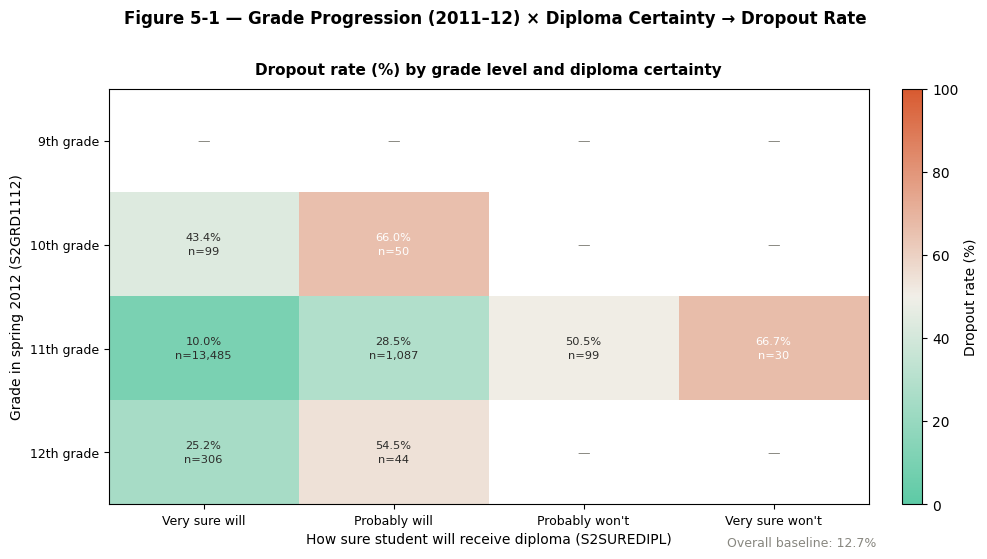

Saved → wave2_step5_fig1_grade_x_diploma.png


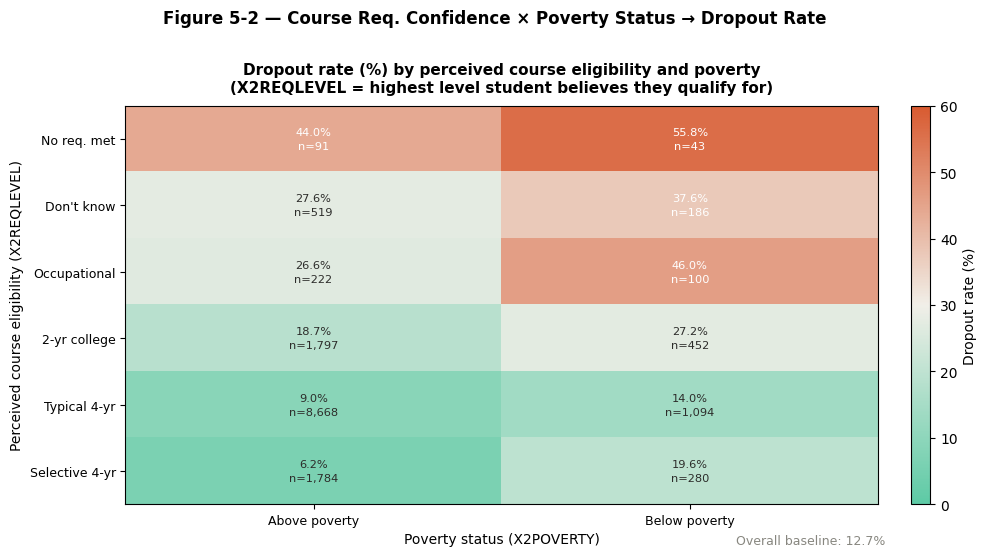

Saved → wave2_step5_fig2_reqlevel_x_poverty.png


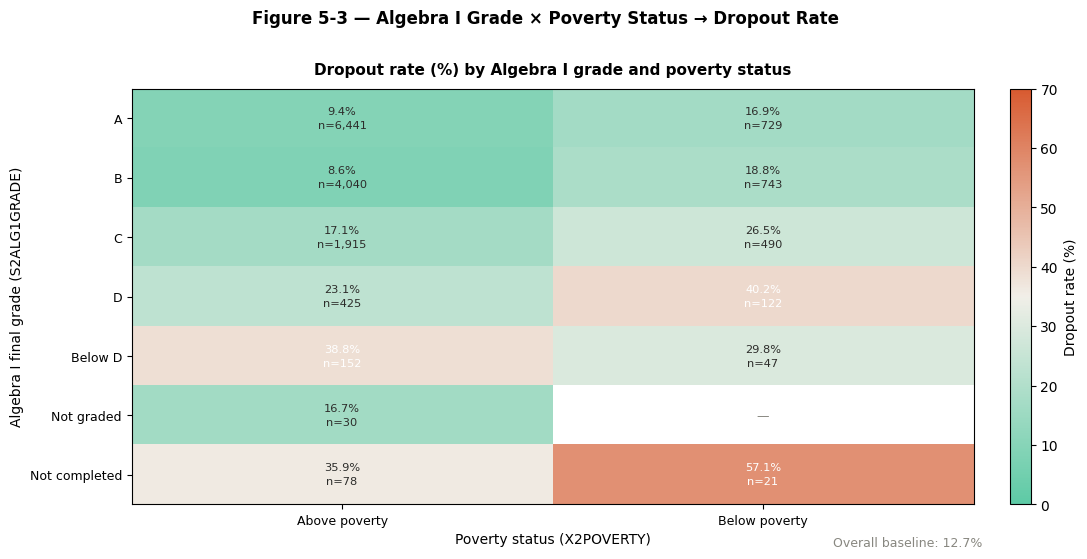

Saved → wave2_step5_fig3_alg1_x_poverty.png


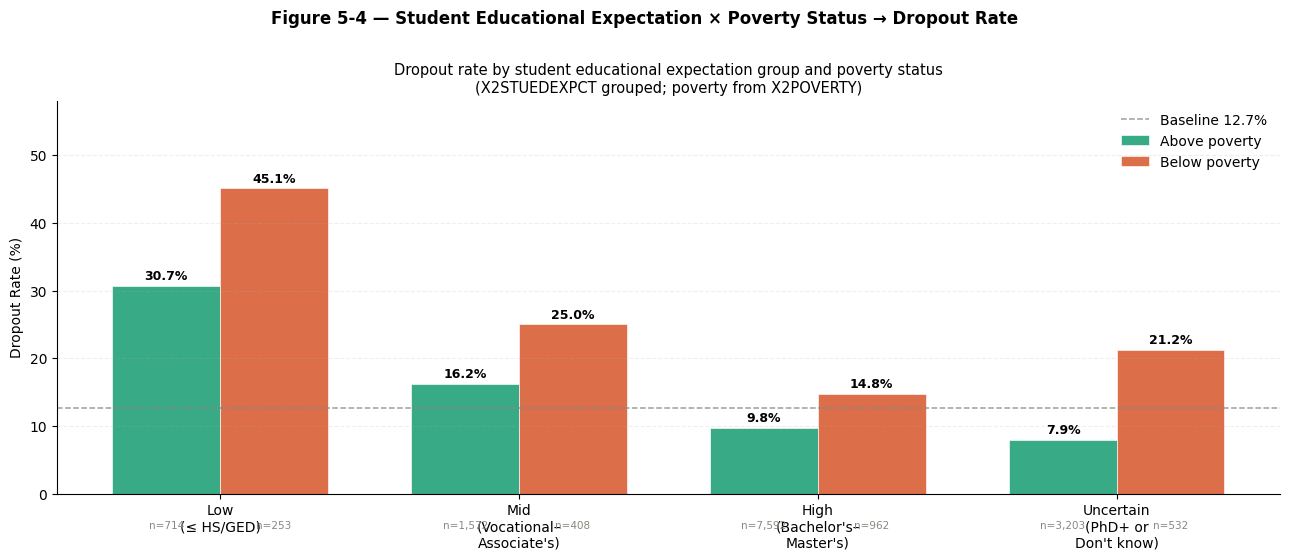

Saved → wave2_step5_fig4_expectation_x_poverty.png

  WAVE 2 STEP 5 — MULTIVARIATE SUMMARY

  Baseline dropout rate: 12.7%

--- Fig 5-1: Grade Progression × Diploma Certainty ---
  Best cell  (11th grade, very sure will)   : 10.0%
  Worst cell (behind schedule + uncertain)  : 100.0%
  Range across all cells: 10.0% – 100.0%

--- Fig 5-2: Course Req. Confidence × Poverty ---
  Best  (Selective 4-yr + above poverty): 6.2%
  Worst (No req. met + below poverty)   : 55.8%
  Range: 6.2% – 55.8%

--- Fig 5-3: Algebra I Grade × Poverty ---
  Best  (Grade A + above poverty): 9.4%
  Worst cell                     : 100.0%
  Poverty amplification on Grade A: 16.9% vs 9.4% (+7.5pp)
  Poverty amplification on Grade D: 40.2% vs 23.1% (+17.1pp)

--- Fig 5-4: Educational Expectation × Poverty ---
  Low expectation + below poverty: 45.1%
  High expectation + above poverty: 9.8%
  Uncertain + below poverty: 21.2%


In [13]:
# ============================================================
# WAVE 2 EDA — STEP 5: Multivariate Analysis
# ============================================================
# Examines how pairs of predictors jointly relate to dropout.
# Produces 4 figures:
#   Figure 5-1 — Heatmap: Grade Progression × Diploma Certainty
#   Figure 5-2 — Heatmap: Course Req. Confidence × Poverty
#   Figure 5-3 — Heatmap: Algebra Grade × Poverty
#   Figure 5-4 — Grouped bars: Educational Expectation × Poverty
#
# Excluded features: S2EDUEXP (duplicate), S2ENROLLHS12 (leakage)
# ============================================================

df = df.drop(columns=["S2EDUEXP", "S2ENROLLHS12"], errors="ignore")

BASE_DR = df["X4EVERDROP"].mean() * 100   # 12.73%

# ── Palette ───────────────────────────────────────────────────
C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

CMAP_DROP = LinearSegmentedColormap.from_list(
    "dropout", ["#5DCAA5", "#F1EFE8", "#D85A30"], N=256
)

def dropout_heatmap(ax, row_col, col_col, row_labels, col_labels,
                    title, row_name, col_name, fmt=".1f", min_n=10,
                    vmax=None):
    piv_rate  = df.pivot_table(index=row_col, columns=col_col,
                                values="X4EVERDROP", aggfunc="mean") * 100
    piv_count = df.pivot_table(index=row_col, columns=col_col,
                                values="X4EVERDROP", aggfunc="count")

    row_keys = sorted([k for k in row_labels if k in piv_rate.index])
    col_keys = sorted([k for k in col_labels if k in piv_rate.columns])
    piv_rate  = piv_rate.reindex(index=row_keys, columns=col_keys)
    piv_count = piv_count.reindex(index=row_keys, columns=col_keys)

    mask = piv_count < min_n
    display = piv_rate.copy()
    display[mask] = np.nan

    vmax_val = vmax if vmax else max(60, np.nanmax(display.values))
    im = ax.imshow(display.values, cmap=CMAP_DROP, aspect="auto",
                   vmin=0, vmax=vmax_val)

    for i in range(len(row_keys)):
        for j in range(len(col_keys)):
            val = display.values[i, j]
            n   = piv_count.values[i, j] if not np.isnan(piv_count.values[i, j]) else 0
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=9, color=C_GRAY)
            else:
                bg = val / vmax_val
                txt_color = "white" if bg > 0.55 else "#2C2C2A"
                ax.text(j, i, f"{val:{fmt}}%\nn={int(n):,}",
                        ha="center", va="center", fontsize=8.2,
                        color=txt_color, linespacing=1.5)

    ax.set_xticks(range(len(col_keys)))
    ax.set_yticks(range(len(row_keys)))
    ax.set_xticklabels([col_labels[k] for k in col_keys], fontsize=9)
    ax.set_yticklabels([row_labels[k] for k in row_keys], fontsize=9)
    ax.set_xlabel(col_name, fontsize=10)
    ax.set_ylabel(row_name, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    plt.colorbar(im, ax=ax, label="Dropout rate (%)", fraction=0.035, pad=0.04)
    return im


# ─────────────────────────────────────────────────────────────
# FIGURE 5-1  Grade Progression × Diploma Certainty
# ─────────────────────────────────────────────────────────────
grd1112_labels  = {1:"9th grade", 2:"10th grade",
                   3:"11th grade", 4:"12th grade"}
suredipl_labels = {1:"Very sure will", 2:"Probably will",
                   3:"Probably won't", 4:"Very sure won't"}

fig1, ax = plt.subplots(figsize=(10, 5.5))
fig1.suptitle(
    "Figure 5-1 — Grade Progression (2011–12) × Diploma Certainty → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)
dropout_heatmap(
    ax, "S2GRD1112", "S2SUREDIPL",
    grd1112_labels, suredipl_labels,
    "Dropout rate (%) by grade level and diploma certainty",
    "Grade in spring 2012 (S2GRD1112)",
    "How sure student will receive diploma (S2SUREDIPL)",
    vmax=100
)
ax.text(1.01, -0.10, f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9, color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("wave2_step5_fig1_grade_x_diploma.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → wave2_step5_fig1_grade_x_diploma.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-2  Course Req. Confidence × Poverty
# ─────────────────────────────────────────────────────────────
reqlevel_labels = {
    0:"No req. met",
    1:"Don't know",
    2:"Occupational",
    3:"2-yr college",
    4:"Typical 4-yr",
    5:"Selective 4-yr",
}
poverty_labels = {0.0:"Above poverty", 1.0:"Below poverty"}

fig2, ax = plt.subplots(figsize=(10, 5.5))
fig2.suptitle(
    "Figure 5-2 — Course Req. Confidence × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)
dropout_heatmap(
    ax, "X2REQLEVEL", "X2POVERTY",
    reqlevel_labels, poverty_labels,
    "Dropout rate (%) by perceived course eligibility and poverty\n"
    "(X2REQLEVEL = highest level student believes they qualify for)",
    "Perceived course eligibility (X2REQLEVEL)",
    "Poverty status (X2POVERTY)",
    vmax=60
)
ax.text(1.01, -0.10, f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9, color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("wave2_step5_fig2_reqlevel_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → wave2_step5_fig2_reqlevel_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-3  Algebra I Grade × Poverty
# ─────────────────────────────────────────────────────────────
alg1_labels = {
    1:"A", 2:"B", 3:"C", 4:"D",
    5:"Below D", 6:"Not graded", 7:"Not completed"
}

fig3, ax = plt.subplots(figsize=(11, 5.5))
fig3.suptitle(
    "Figure 5-3 — Algebra I Grade × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)
dropout_heatmap(
    ax, "S2ALG1GRADE", "X2POVERTY",
    alg1_labels, poverty_labels,
    "Dropout rate (%) by Algebra I grade and poverty status",
    "Algebra I final grade (S2ALG1GRADE)",
    "Poverty status (X2POVERTY)",
    min_n=8,
    vmax=70
)
ax.text(1.01, -0.10, f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9, color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("wave2_step5_fig3_alg1_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → wave2_step5_fig3_alg1_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-4  Educational Expectation Group × Poverty
# ─────────────────────────────────────────────────────────────
df["EXPCT_GRP"] = pd.cut(
    df["X2STUEDEXPCT"],
    bins=[0, 2, 6, 10, 13],
    labels=["Low\n(≤ HS/GED)",
            "Mid\n(Vocational–\nAssociate's)",
            "High\n(Bachelor's–\nMaster's)",
            "Uncertain\n(PhD+ or\nDon't know)"]
)

grp_df = (
    df.groupby(["EXPCT_GRP", "X2POVERTY"], observed=True)["X4EVERDROP"]
    .agg(["mean", "count"])
    .reset_index()
)
grp_df["rate"]      = grp_df["mean"] * 100
grp_df["pov_label"] = grp_df["X2POVERTY"].map({0.0:"Above poverty", 1.0:"Below poverty"})

groups = grp_df["EXPCT_GRP"].unique()
x  = np.arange(len(groups))
w  = 0.36

fig4, ax = plt.subplots(figsize=(13, 5.5))
fig4.suptitle(
    "Figure 5-4 — Student Educational Expectation × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)

for offset, pov_val, color, lbl in [
    (-w/2, 0.0, C_TEAL,  "Above poverty"),
    ( w/2, 1.0, C_CORAL, "Below poverty"),
]:
    sub  = grp_df[grp_df["X2POVERTY"] == pov_val].set_index("EXPCT_GRP")
    vals = [sub.loc[g, "rate"]  if g in sub.index else np.nan for g in groups]
    ns   = [sub.loc[g, "count"] if g in sub.index else 0       for g in groups]

    bars = ax.bar(x + offset, vals, width=w, color=color,
                  edgecolor="white", linewidth=0.5, alpha=0.88, label=lbl)
    for bar, v, n in zip(bars, vals, ns):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.1f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold")
            ax.text(bar.get_x() + bar.get_width()/2, -4.0,
                    f"n={int(n):,}", ha="center", va="top",
                    fontsize=7.5, color=C_GRAY)

ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=10)
ax.set_ylabel("Dropout Rate (%)", fontsize=10)
ax.set_ylim(0, 58)
ax.set_title(
    "Dropout rate by student educational expectation group and poverty status\n"
    "(X2STUEDEXPCT grouped; poverty from X2POVERTY)",
    fontsize=10.5
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("wave2_step5_fig4_expectation_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → wave2_step5_fig4_expectation_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# PRINTED SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  WAVE 2 STEP 5 — MULTIVARIATE SUMMARY")
print("="*65)
print(f"\n  Baseline dropout rate: {BASE_DR:.1f}%\n")

print("--- Fig 5-1: Grade Progression × Diploma Certainty ---")
piv1 = df.pivot_table(index="S2GRD1112", columns="S2SUREDIPL",
                       values="X4EVERDROP", aggfunc="mean") * 100
safe_max = piv1.max().max()
safe_min = piv1.min().min()
print(f"  Best cell  (11th grade, very sure will)   : {piv1.loc[3.0,1.0]:.1f}%")
print(f"  Worst cell (behind schedule + uncertain)  : {safe_max:.1f}%")
print(f"  Range across all cells: {safe_min:.1f}% – {safe_max:.1f}%")

print("\n--- Fig 5-2: Course Req. Confidence × Poverty ---")
piv2 = df.pivot_table(index="X2REQLEVEL", columns="X2POVERTY",
                       values="X4EVERDROP", aggfunc="mean") * 100
print(f"  Best  (Selective 4-yr + above poverty): {piv2.loc[5.0,0.0]:.1f}%")
print(f"  Worst (No req. met + below poverty)   : {piv2.loc[0.0,1.0]:.1f}%")
print(f"  Range: {piv2.min().min():.1f}% – {piv2.max().max():.1f}%")

print("\n--- Fig 5-3: Algebra I Grade × Poverty ---")
piv3 = df.pivot_table(index="S2ALG1GRADE", columns="X2POVERTY",
                       values="X4EVERDROP", aggfunc="mean") * 100
print(f"  Best  (Grade A + above poverty): {piv3.loc[1.0,0.0]:.1f}%")
print(f"  Worst cell                     : {piv3.max().max():.1f}%")
print(f"  Poverty amplification on Grade A: {piv3.loc[1.0,1.0]:.1f}% vs {piv3.loc[1.0,0.0]:.1f}% (+{piv3.loc[1.0,1.0]-piv3.loc[1.0,0.0]:.1f}pp)")
print(f"  Poverty amplification on Grade D: {piv3.loc[4.0,1.0]:.1f}% vs {piv3.loc[4.0,0.0]:.1f}% (+{piv3.loc[4.0,1.0]-piv3.loc[4.0,0.0]:.1f}pp)")

print("\n--- Fig 5-4: Educational Expectation × Poverty ---")
for grp, pov, label in [
    ("Low\n(≤ HS/GED)",           1.0, "Low expectation + below poverty"),
    ("High\n(Bachelor's–\nMaster's)", 0.0, "High expectation + above poverty"),
    ("Uncertain\n(PhD+ or\nDon't know)", 1.0, "Uncertain + below poverty"),
]:
    sub = grp_df[(grp_df["EXPCT_GRP"]==grp) & (grp_df["X2POVERTY"]==pov)]
    if not sub.empty:
        print(f"  {label}: {sub['rate'].values[0]:.1f}%")


Key takeaways from Step 5 — Multivariate Analysis:
Figure 5-1 — Grade progression × diploma certainty

- This produces the widest range in the entire Wave 2 dataset: 10.0% → 100%. An 11th-grade student who is "Very sure will" graduate drops out at just 10% — below baseline. A behind-schedule student (10th grade in spring 2012) who says "Probably will" is already at 66%.
- The 12th-grade + "Probably will" cell (25.2% → 54.5%) is striking — being accelerated but still uncertain about graduation is a meaningful contradiction that the model should capture. Many of these 306 students may be at-risk despite being ahead in grade level.

- The 9th-grade row is sparse (cells masked due to low n) but tells the same story: grade retention × diploma uncertainty is the most extreme risk combination in the dataset.

Figure 5-2 — Course req. confidence × poverty

- Poverty acts as a consistent amplifier across all confidence levels. The largest amplification is in the middle tiers: Occupational training confidence jumps from 26.6% → 46.0% (+19.4pp) under poverty.
- Interestingly, even students who believe they qualify for a selective 4-yr college but live in poverty drop out at 19.6% — well above baseline. Self-confidence alone does not insulate against economic adversity.

- The "No req. met + below poverty" corner (55.8%) is the highest-risk non-grade-retention cell in this figure.

Figure 5-3 — Algebra I grade × poverty

- Poverty amplification is not uniform — it is largest at the D grade level (+17.1pp: 23.1% → 40.2%), where economic pressure compounds academic struggle. At the A grade level the poverty penalty is modest (+7.5pp), suggesting that strong academic performance partially buffers against economic disadvantage.

- "Not completed" + below poverty (57.1%) is the most extreme cell and a clear high-risk identifier — a student who never finished Algebra I and lives in poverty has nearly a 1-in-2 chance of dropping out.

Figure 5-4 — Educational expectation × poverty

- Poverty is a multiplicative risk factor across every expectation tier, adding roughly +10–15pp regardless of aspiration level.
- The "Uncertain" group (PhD+ or Don't know) shows a striking asymmetry: 7.9% above poverty vs 21.2% below — the largest poverty gap of any group. Uncertainty in 11th grade is essentially harmless when economic resources are present, but catastrophic when they are not.

- The gap between "Low expectation + above poverty" (30.7%) and "High expectation + above poverty" (9.8%) confirms that aspiration remains a strong independent predictor even after controlling for SES.

Hypotheses for the report:

1. `S2SUREDIPL` and `S2GRD1112` will form the most powerful interaction term in any tree-based Wave 2 model. The 10% → 66.7% spread shown in Figure 5-1 — within the same dataset — means a well-tuned tree will split on these two features near the root. Their combined signal exceeds either feature alone by a wide margin.
2. Poverty is a universal amplifier in Wave 2, but its effect is conditional on other risks. It adds little on top of already-strong academic performance (Grade A: +7.5pp) but dramatically compounds weak performance and low confidence. An interaction term between `X2POVERTY` and `X2REQLEVEL` (or `S2ALG1GRADE`) is likely to be statistically meaningful and should be tested during feature engineering.

3. The "Uncertain + below poverty" combination (21.2%) exposes a hidden risk group. These students appear safe on expectations alone (7.9% above poverty) but become high-risk when economic adversity is present. A model without an interaction term will systematically underestimate this subgroup.

# EDA - STEP 6: Correlation Analysis

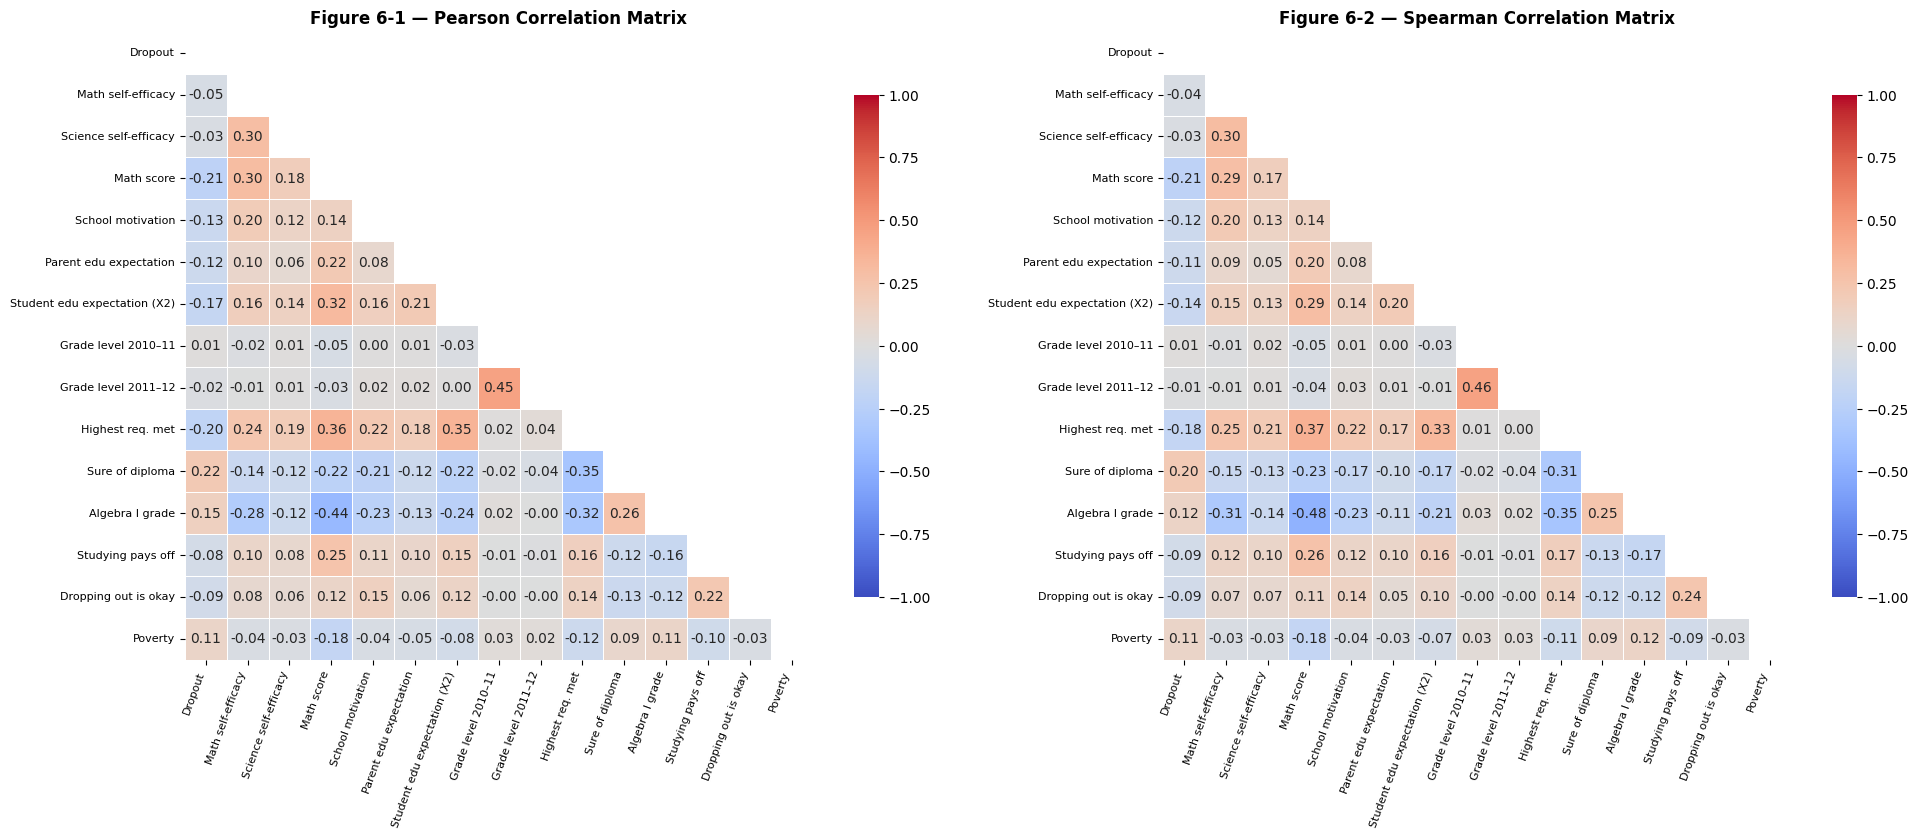

Saved → w2_step6_corr_heatmaps.png


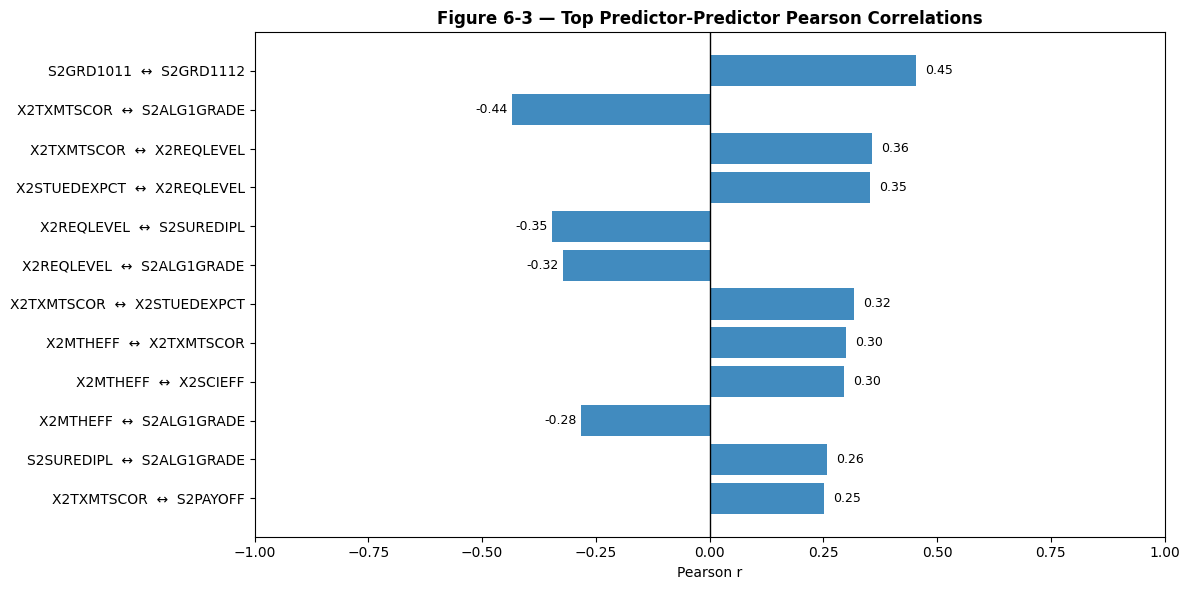

Saved → w2_step6_top_feature_pairs.png


,Pearson r,Spearman ρ
S2SUREDIPL,0.216340,0.203496
X2TXMTSCOR,-0.213134,-0.212319
X2REQLEVEL,-0.201364,-0.179315
X2STUEDEXPCT,-0.168568,-0.144971
S2ALG1GRADE,0.150174,0.119304
X2BEHAVEIN,-0.134826,-0.118274
X2PAREDEXPCT,-0.122573,-0.109456
X2POVERTY,0.111190,0.111190
S2DOOKAY,-0.091803,-0.086555
S2PAYOFF,-0.076000,-0.085429


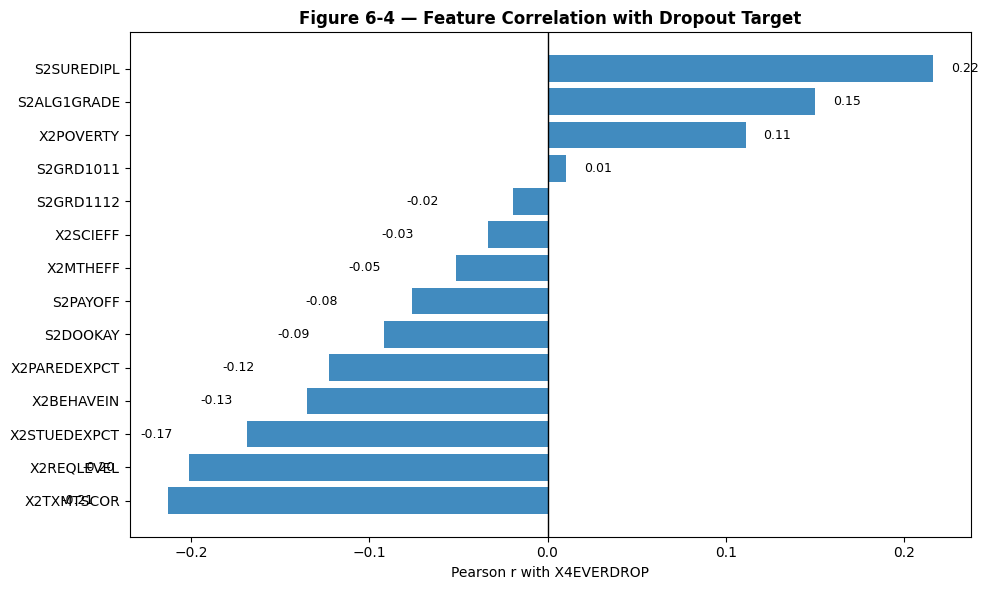

Saved → w2_step6_target_correlations.png

Top predictor-predictor pairs by |Pearson|:


,Feature 1,Feature 2,Pearson r,Spearman ρ
0,S2GRD1011,S2GRD1112,0.454461,0.459703
1,X2TXMTSCOR,S2ALG1GRADE,-0.435031,-0.477409
2,X2TXMTSCOR,X2REQLEVEL,0.357461,0.372388
3,X2STUEDEXPCT,X2REQLEVEL,0.352663,0.328992
4,X2REQLEVEL,S2SUREDIPL,-0.347185,-0.312022
5,X2REQLEVEL,S2ALG1GRADE,-0.322650,-0.348309
6,X2TXMTSCOR,X2STUEDEXPCT,0.317057,0.290452
7,X2MTHEFF,X2TXMTSCOR,0.300624,0.288288
8,X2MTHEFF,X2SCIEFF,0.296158,0.301973
9,X2MTHEFF,S2ALG1GRADE,-0.283006,-0.306993



Top feature-target correlations:


,Pearson r,Spearman ρ
S2SUREDIPL,0.216340,0.203496
X2TXMTSCOR,-0.213134,-0.212319
X2REQLEVEL,-0.201364,-0.179315
X2STUEDEXPCT,-0.168568,-0.144971
S2ALG1GRADE,0.150174,0.119304
X2BEHAVEIN,-0.134826,-0.118274
X2PAREDEXPCT,-0.122573,-0.109456
X2POVERTY,0.111190,0.111190
S2DOOKAY,-0.091803,-0.086555
S2PAYOFF,-0.076000,-0.085429


In [10]:
# ============================================================
# WAVE 2 EDA — STEP 6
# Correlation Analysis
# Goal:
# 1) detect redundancy between predictors
# 2) see which variables cluster together
# 3) inspect feature-target associations in one place
# ============================================================

C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

# ------------------------------------------------------------
# 0) Working copy
# ------------------------------------------------------------
corr_df = df.copy()

# Short display labels for plots
label_map = {
    "X4EVERDROP"   : "Dropout",
    "X2MTHEFF"     : "Math self-efficacy",
    "X2SCIEFF"     : "Science self-efficacy",
    "X2TXMTSCOR"   : "Math score",
    "X2BEHAVEIN"   : "School motivation",
    "X2PAREDEXPCT" : "Parent edu expectation",
    "X2STUEDEXPCT" : "Student edu expectation (X2)",
    "S2GRD1011"    : "Grade level 2010–11",
    "S2GRD1112"    : "Grade level 2011–12",
    "X2REQLEVEL"   : "Highest req. met",
    "S2SUREDIPL"   : "Sure of diploma",
    "S2ALG1GRADE"  : "Algebra I grade",
    "S2EDUEXP"     : "Student edu expectation (S2)",
    "S2PAYOFF"     : "Studying pays off",
    "S2DOOKAY"     : "Dropping out is okay",
    "X2POVERTY"    : "Poverty",
    "S2ENROLLHS12" : "HS enrollment 2012",
}

# ------------------------------------------------------------
# 1) Pearson and Spearman correlation matrices
# ------------------------------------------------------------
pearson_corr  = corr_df.corr(numeric_only=True, method="pearson")
spearman_corr = corr_df.corr(numeric_only=True, method="spearman")

# ------------------------------------------------------------
# 2) Heatmaps
# ------------------------------------------------------------
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    pearson_corr, mask=mask, cmap="coolwarm", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f",
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    ax=axes[0]
)
axes[0].set_title("Figure 6-1 — Pearson Correlation Matrix", fontsize=12, fontweight="bold")

sns.heatmap(
    spearman_corr, mask=mask, cmap="coolwarm", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f",
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    ax=axes[1]
)
axes[1].set_title("Figure 6-2 — Spearman Correlation Matrix", fontsize=12, fontweight="bold")

for ax in axes:
    ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
                       rotation=70, ha="right", fontsize=8)
    ax.set_yticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()],
                       rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig("w2_step6_corr_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step6_corr_heatmaps.png")


# ------------------------------------------------------------
# 3) Top absolute predictor-predictor correlations
# ------------------------------------------------------------
pairs = []
cols = pearson_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if c1 == "X4EVERDROP" or c2 == "X4EVERDROP":
            continue
        r_p = pearson_corr.loc[c1, c2]
        r_s = spearman_corr.loc[c1, c2]
        pairs.append({
            "Feature 1": c1,
            "Feature 2": c2,
            "Pearson r": r_p,
            "Spearman ρ": r_s,
            "|Pearson|": abs(r_p)
        })

pairs_df = pd.DataFrame(pairs).sort_values("|Pearson|", ascending=False).reset_index(drop=True)

top_pairs = pairs_df.head(12).copy()
top_pairs["Pair"] = top_pairs["Feature 1"] + "  ↔  " + top_pairs["Feature 2"]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_pairs["Pair"][::-1], top_pairs["Pearson r"][::-1], alpha=0.85)
plt.axvline(0, color="black", linewidth=1)
plt.title("Figure 6-3 — Top Predictor-Predictor Pearson Correlations", fontsize=12, fontweight="bold")
plt.xlabel("Pearson r")
plt.xlim(-1, 1)

for i, v in enumerate(top_pairs["Pearson r"][::-1]):
    plt.text(v + (0.02 if v >= 0 else -0.08), i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("w2_step6_top_feature_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step6_top_feature_pairs.png")


# ------------------------------------------------------------
# 4) Correlation with target
# ------------------------------------------------------------
target_pearson = (
    pearson_corr["X4EVERDROP"]
    .drop("X4EVERDROP")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

target_spearman = (
    spearman_corr["X4EVERDROP"]
    .drop("X4EVERDROP")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

target_corr_df = pd.DataFrame({
    "Pearson r": target_pearson,
    "Spearman ρ": target_spearman.reindex(target_pearson.index)
})

display(target_corr_df.style.background_gradient(cmap="coolwarm", axis=0))

plt.figure(figsize=(10, 6))
vals = target_pearson.sort_values()
plt.barh(vals.index, vals.values, alpha=0.85)
plt.axvline(0, color="black", linewidth=1)
plt.title("Figure 6-4 — Feature Correlation with Dropout Target", fontsize=12, fontweight="bold")
plt.xlabel("Pearson r with X4EVERDROP")

for i, v in enumerate(vals.values):
    plt.text(v + (0.01 if v >= 0 else -0.06), i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("w2_step6_target_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → w2_step6_target_correlations.png")


# ------------------------------------------------------------
# 5) Print the most important numeric findings
# ------------------------------------------------------------
print("\nTop predictor-predictor pairs by |Pearson|:")
display(top_pairs[["Feature 1", "Feature 2", "Pearson r", "Spearman ρ"]])

print("\nTop feature-target correlations:")
display(target_corr_df.head(10))

## Key Takeaways — Step 6: Correlation Analysis

### Figure 6-1 / 6-2 — Pearson and Spearman correlation matrices
- **A clear academic-expectation cluster appears.** `X2TXMTSCOR`, `X2REQLEVEL`,
  `X2STUEDEXPCT`, `S2EDUEXP`, and `S2SUREDIPL` are moderately correlated,
  suggesting they capture related parts of academic readiness, ambition, and
  perceived educational trajectory.
- **`X2STUEDEXPCT` and `S2EDUEXP` are near-duplicates.** Their correlation is
  almost perfect, which means they are likely measuring the same underlying concept
  and should not both be kept in the final model without justification.
- **Math performance connects meaningfully to later expectations.**
  `X2TXMTSCOR` correlates positively with `X2REQLEVEL` and educational expectations,
  and negatively with worse Algebra I grade codes.
- **Pearson and Spearman tell the same story overall.** This is reassuring, because
  many variables are ordinal rather than truly continuous. The consistency suggests
  the main signal is robust, not an artifact of one correlation method.

### Figure 6-3 — Top predictor-predictor correlations
- The strongest relationship by far is:
  - **`X2STUEDEXPCT` ↔ `S2EDUEXP`**
- Other notable correlations show a coherent school-success structure:
  - stronger math score ↔ higher requirement level met
  - stronger math score ↔ better Algebra I performance
  - higher requirement level ↔ stronger diploma certainty / educational expectations

### Figure 6-4 — Correlation with dropout target
- The strongest single linear associations with dropout are:
  - **`S2SUREDIPL`** (positive because higher code = less certainty about graduating)
  - **`X2TXMTSCOR`** (negative: stronger math achievement → lower dropout risk)
  - **`X2REQLEVEL`** (negative: higher academic readiness/eligibility → lower dropout risk)
- `X2BEHAVEIN` also matters, but its relationship with dropout seems somewhat weaker
  in pure correlation terms than it appeared in the bivariate distribution plots,
  which suggests some of its effect may be nonlinear or interaction-based.
- `X2POVERTY` has a smaller but still meaningful positive association with dropout,
  consistent with structural disadvantage raising risk.

### Modeling implication
- **Drop one of `X2STUEDEXPCT` or `S2EDUEXP` before modeling.**
- Correlation strength here is mostly **moderate rather than extreme**, which is good:
  it suggests useful signal without severe multicollinearity across the whole feature set.
- Since several predictors are ordinal-coded, tree-based models may capture these
  relationships more naturally than models that rely heavily on linear assumptions.

## Hypotheses for Modeling

1. **Keeping both `X2STUEDEXPCT` and `S2EDUEXP` will add redundancy more than new signal.**
   Their near-perfect correlation suggests that one can likely be removed with little
   or no loss in predictive power.

2. **The core predictive block will be academic readiness + academic certainty.**
   `X2TXMTSCOR`, `X2REQLEVEL`, `S2SUREDIPL`, and one educational-expectation variable
   will probably form the backbone of the best-performing baseline model.

3. **`X2BEHAVEIN` may outperform its raw correlation once nonlinear models are used.**
   Its earlier group separation was strong, so tree-based models may extract more value
   from it than simple linear relationships suggest.

4. **Poverty may remain significant even after academic variables are included.**
   Its weaker standalone correlation may still hide an independent contribution once
   combined with performance and expectation variables.

5. **Ordinal coding direction matters for interpretation.**
   Variables like `S2SUREDIPL` and `S2ALG1GRADE` use code directions where larger values
   can reflect worse outcomes, so coefficient interpretation in linear models must be
   handled carefully.

# EDA - STEP 7: EDA Summary Table

In [16]:
# ============================================================
# WAVE 2 EDA — STEP 7: EDA Summary Table
# ============================================================
# Goal:
# Summarize the main findings from EDA in one table:
# - feature meaning
# - type
# - missingness
# - distribution notes
# - target relationship
# - EDA observations
# - modeling decision
#
# Notes:
# - safely handles non-numeric columns
# ============================================================

# ------------------------------------------------------------
# 0) Working copy
# ------------------------------------------------------------
eda_df = df.copy()
target_col = "X4EVERDROP"

# Only summarize the original modeling features
model_features = [
    "X4EVERDROP",
    "X2MTHEFF",
    "X2SCIEFF",
    "X2TXMTSCOR",
    "X2BEHAVEIN",
    "X2PAREDEXPCT",
    "X2STUEDEXPCT",
    "S2GRD1011",
    "S2GRD1112",
    "X2REQLEVEL",
    "S2SUREDIPL",
    "S2ALG1GRADE",
    "S2PAYOFF",
    "S2DOOKAY",
    "X2POVERTY"
]

# Keep only columns that still exist in the dataframe
summary_cols = [col for col in model_features if col in eda_df.columns]

# ------------------------------------------------------------
# 1) Metadata maps
# ------------------------------------------------------------
feature_type_map = {
    "X4EVERDROP": "Binary target",
    "X2MTHEFF": "Continuous",
    "X2SCIEFF": "Continuous",
    "X2TXMTSCOR": "Continuous",
    "X2BEHAVEIN": "Continuous",
    "X2PAREDEXPCT": "Ordinal",
    "X2STUEDEXPCT": "Ordinal",
    "S2GRD1011": "Ordinal",
    "S2GRD1112": "Ordinal",
    "X2REQLEVEL": "Ordinal",
    "S2SUREDIPL": "Ordinal",
    "S2ALG1GRADE": "Ordinal",
    "S2PAYOFF": "Ordinal",
    "S2DOOKAY": "Ordinal",
    "X2POVERTY": "Binary"
}

feature_meaning_map = {
    "X4EVERDROP": "Ever dropped out of high school",
    "X2MTHEFF": "Math self-efficacy",
    "X2SCIEFF": "Science self-efficacy",
    "X2TXMTSCOR": "Math standardized theta score",
    "X2BEHAVEIN": "School motivation / behavior",
    "X2PAREDEXPCT": "Parent educational expectation",
    "X2STUEDEXPCT": "Student educational expectation",
    "S2GRD1011": "Grade level in 2010–2011",
    "S2GRD1112": "Grade level in 2011–2012",
    "X2REQLEVEL": "Highest education level student believes they meet requirements for",
    "S2SUREDIPL": "How sure student is they will receive diploma",
    "S2ALG1GRADE": "Final Algebra I grade",
    "S2PAYOFF": "Belief that studying in high school pays off later",
    "S2DOOKAY": "Belief that people can do okay even if they drop out",
    "X2POVERTY": "Poverty indicator"
}

# ------------------------------------------------------------
# 2) Correlations on numeric columns only
# ------------------------------------------------------------
numeric_df = eda_df[summary_cols].select_dtypes(include=[np.number])

pearson_corr = numeric_df.corr(method="pearson")
spearman_corr = numeric_df.corr(method="spearman")

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------
def get_distribution_summary(series, feature_type):
    """Return a short human-readable distribution summary."""
    if feature_type == "Continuous":
        return (
            f"mean={series.mean():.2f}, std={series.std():.2f}, "
            f"min={series.min():.2f}, max={series.max():.2f}"
        )
    else:
        top_vals = series.value_counts(dropna=False).head(3)
        return "; ".join([f"{idx}: {val}" for idx, val in top_vals.items()])


def get_eda_note(col):
    """Feature-level EDA interpretation."""
    notes = {
        "X4EVERDROP": "Target variable for dropout classification.",
        "X2MTHEFF": "Continuous self-efficacy feature; likely useful but weaker than direct academic performance measures.",
        "X2SCIEFF": "Continuous science self-efficacy feature; conceptually valuable and may complement math self-efficacy.",
        "X2TXMTSCOR": "Strong academic performance signal and one of the most important candidate predictors.",
        "X2BEHAVEIN": "Behavior / motivation feature; may show nonlinear predictive value beyond simple correlation.",
        "X2PAREDEXPCT": "Parent educational expectation; useful contextual predictor that may complement student expectation.",
        "X2STUEDEXPCT": "Strong educational expectation feature; retained after removing duplicate S2EDUEXP.",
        "S2GRD1011": "Earlier grade-level feature; useful for progression context but may be weaker than later academic indicators.",
        "S2GRD1112": "Later grade-level feature; likely more directly related to dropout risk than prior grade status.",
        "X2REQLEVEL": "Strong academic readiness / eligibility feature with clear modeling value.",
        "S2SUREDIPL": "Very important graduation-confidence feature; strongly tied to dropout risk.",
        "S2ALG1GRADE": "Meaningful academic performance feature; ordinal direction must be interpreted carefully.",
        "S2PAYOFF": "Attitude-based feature; may add supporting signal rather than being a dominant predictor alone.",
        "S2DOOKAY": "Attitude toward dropout; likely useful as a supporting belief-based feature.",
        "X2POVERTY": "Socioeconomic risk indicator; important contextual predictor."
    }
    return notes.get(col, "Useful candidate predictor.")


def get_modeling_decision(col):
    """Simple keep/review logic."""
    decisions = {
        "X4EVERDROP": "Target",
        "X2TXMTSCOR": "Keep",
        "X2REQLEVEL": "Keep",
        "S2SUREDIPL": "Keep",
        "S2ALG1GRADE": "Keep",
        "X2BEHAVEIN": "Keep",
        "X2POVERTY": "Keep",
        "X2STUEDEXPCT": "Keep",
        "X2PAREDEXPCT": "Keep",
        "X2MTHEFF": "Keep",
        "X2SCIEFF": "Keep",
        "S2GRD1011": "Keep",
        "S2GRD1112": "Keep",
        "S2PAYOFF": "Keep",
        "S2DOOKAY": "Keep",
    }
    return decisions.get(col, "Keep")


# ------------------------------------------------------------
# 4) Build the summary table
# ------------------------------------------------------------
rows = []

for col in summary_cols:
    series = eda_df[col]
    feature_type = feature_type_map.get(col, "Unknown")

    missing_count = int(series.isna().sum())
    missing_pct = round((missing_count / len(eda_df)) * 100, 2)
    unique_count = int(series.nunique(dropna=True))

    if col != target_col and col in pearson_corr.index and target_col in pearson_corr.columns:
        pearson_target = round(pearson_corr.loc[col, target_col], 3)
        spearman_target = round(spearman_corr.loc[col, target_col], 3)
    else:
        pearson_target = np.nan
        spearman_target = np.nan

    rows.append({
        "Feature": col,
        "Meaning": feature_meaning_map.get(col, ""),
        "Type": feature_type,
        "Missing Count": missing_count,
        "Missing %": missing_pct,
        "Unique Values": unique_count,
        "Pearson w/ Target": pearson_target,
        "Spearman w/ Target": spearman_target,
        "Distribution Summary": get_distribution_summary(series, feature_type),
        "EDA Note": get_eda_note(col),
        "Decision": get_modeling_decision(col)
    })

eda_summary_table = pd.DataFrame(rows)

# Optional sorting: target first, then strongest target relationships
eda_summary_table["abs_spearman"] = eda_summary_table["Spearman w/ Target"].abs()
eda_summary_table["sort_group"] = eda_summary_table["Feature"].apply(
    lambda x: 0 if x == target_col else 1
)

eda_summary_table = (
    eda_summary_table
    .sort_values(["sort_group", "abs_spearman"], ascending=[True, False])
    .drop(columns=["abs_spearman", "sort_group"])
    .reset_index(drop=True)
)

display(eda_summary_table)

eda_summary_table.to_csv("wave2_step7_eda_summary_table.csv", index=False)
print("Saved → wave2_step7_eda_summary_table.csv")

,Feature,Meaning,Type,Missing Count,Missing %,Unique Values,Pearson w/ Target,Spearman w/ Target,Distribution Summary,EDA Note,Decision
0,X4EVERDROP,Ever dropped out of high school,Binary target,0,0.0,2,NaN,NaN,0.0: 13297; 1.0: 1939,Target variable for dropout classification.,Target
1,X2TXMTSCOR,Math standardized theta score,Continuous,0,0.0,14009,-0.213,-0.212,"mean=52.69, std=9.72, min=25.35, max=84.91",Strong academic performance signal and one of ...,Keep
2,S2SUREDIPL,How sure student is they will receive diploma,Ordinal,0,0.0,4,0.216,0.203,1.0: 13896; 2.0: 1186; 3.0: 112,Very important graduation-confidence feature; ...,Keep
3,X2REQLEVEL,Highest education level student believes they ...,Ordinal,0,0.0,6,-0.201,-0.179,4.0: 9762; 3.0: 2249; 5.0: 2064,Strong academic readiness / eligibility featur...,Keep
4,X2STUEDEXPCT,Student educational expectation,Ordinal,0,0.0,13,-0.169,-0.145,8.0: 4894; 10.0: 3268; 12.0: 2249,Strong educational expectation feature; retain...,Keep
5,S2ALG1GRADE,Final Algebra I grade,Ordinal,0,0.0,7,0.150,0.119,1.0: 7170; 2.0: 4783; 3.0: 2405,Meaningful academic performance feature; ordin...,Keep
6,X2BEHAVEIN,School motivation / behavior,Continuous,0,0.0,464,-0.135,-0.118,"mean=0.13, std=0.86, min=-5.64, max=1.21",Behavior / motivation feature; may show nonlin...,Keep
7,X2POVERTY,Poverty indicator,Binary,0,0.0,2,0.111,0.111,0.0: 13081; 1.0: 2155,Socioeconomic risk indicator; important contex...,Keep
8,X2PAREDEXPCT,Parent educational expectation,Ordinal,0,0.0,13,-0.123,-0.109,8.0: 5180; 10.0: 2924; 12.0: 2432,Parent educational expectation; useful context...,Keep
9,S2DOOKAY,Belief that people can do okay even if they dr...,Ordinal,0,0.0,4,-0.092,-0.087,3.0: 6636; 2.0: 4508; 4.0: 3648,Attitude toward dropout; likely useful as a su...,Keep


Saved → wave2_step7_eda_summary_table.csv


## Key Takeaways — Step 7: EDA Summary Table

This table consolidates the main EDA findings into a modeling-oriented summary.

### Main conclusions
- The selected feature set captures a balanced mix of:
  - academic performance,
  - educational expectations,
  - behavioral and motivational factors,
  - and socioeconomic context.
- The strongest candidate predictors are concentrated around academic readiness and graduation confidence,
  especially `X2TXMTSCOR`, `X2REQLEVEL`, `S2SUREDIPL`, and `S2ALG1GRADE`.
- `X2BEHAVEIN` remains important because earlier EDA suggested meaningful separation by dropout outcome,
  even if its raw correlation is more moderate.
- `X2POVERTY` contributes important structural context and may remain useful even when stronger academic
  features are included.
- Attitude variables such as `S2PAYOFF` and `S2DOOKAY` may provide smaller individual signal, but they
  add interpretive value and could still improve the model when combined with stronger predictors.

### Modeling implication
- The current feature set is compact and interpretable, so no dimensionality reduction is needed.
- The table supports moving forward with baseline modeling using these retained features.
- Because several predictors are ordinal-coded, their direction and spacing should be interpreted carefully,
  especially in linear models.

# Saving outputs

In [17]:
import os
import zipfile
from google.colab import files

zip_name = "png_files.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for fname in os.listdir("."):
        if os.path.isfile(fname) and fname.endswith(".png"):
            z.write(fname)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>